# Baseline Classification for BSR Presence Prediction

This notebook trains baseline classification models to predict whether a product has a BSR rank:
- **TARGET 1**: `has_main_bsr` - Binary classification: Does product have a main BSR rank? (0=No, 1=Yes)
- **TARGET 2**: `has_lowest_bsr` - Binary classification: Does product have any BSR rank? (0=No, 1=Yes)

**Models Used:**
1. **Logistic Regression (L2 Regularized)** - Equivalent to Ridge for classification
2. **XGBoost Classifier** - Gradient boosting for non-linear patterns
3. **Random Forest Classifier** - Ensemble tree-based classifier

For each target, we train models using:
1. **Top Features Model**: Using only the top-ranked features from EDA
2. **All Features Model**: Using all available image features

**Important**: Features for one target do NOT include the other target to avoid data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color scheme for binary classification
CLASS_0_COLOR = '#E74C3C'      # Red for No BSR (class 0)
CLASS_1_COLOR = '#27AE60'      # Green for Has BSR (class 1)
MODEL_COLORS = {'LogisticRegression': '#3498DB', 'XGBoost': '#E67E22', 'RandomForest': '#9B59B6'}

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================

DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

# Create binary classification targets
df['has_main_bsr'] = df['main_bsr_rank'].notna().astype(int)
df['has_lowest_bsr'] = df['lowest_bsr_rank'].notna().astype(int)

# Filter to products with image features
df = df[df['num_images'].notna()].copy()

print(f"Dataset shape: {df.shape}")
print(f"\nTarget Distribution:")
print(f"has_main_bsr:   Class 0: {(df['has_main_bsr']==0).sum():,} | Class 1: {(df['has_main_bsr']==1).sum():,}")
print(f"has_lowest_bsr: Class 0: {(df['has_lowest_bsr']==0).sum():,} | Class 1: {(df['has_lowest_bsr']==1).sum():,}")

Dataset shape: (36879, 7654)

Target Distribution:
has_main_bsr:   Class 0: 11,113 | Class 1: 25,766
has_lowest_bsr: Class 0: 11,113 | Class 1: 25,766


In [3]:
# =============================================================================
# 2. DEFINE FEATURE SETS
# =============================================================================

# Columns to EXCLUDE from features (targets, metadata, identifiers)
# Columns to EXCLUDE - metadata, identifiers, and POST-LISTING metrics
# (features not available when predicting for a NEW product)
EXCLUDE_COLS = [
    # Identifiers and metadata
    'Unnamed: 0.1', 'Unnamed: 0', 'asin', 'category', 'query', 'page',
    'source_section', 'type', 'title', 'image', 'url', 'optimized_url',
    'delivery', 'price_string', 'price_symbol', 'colors', 'location',
    'search_message', 'sd_feature_bullets_text', 'sd_title', 'sd_parent_asin',
    'sd_price_symbol', 'sd_availability_status', 'sd_product_category',
    'sd_category_id', 'sd_ratings_distribution', 'sd_customer_sentiments',
    'sd_error', 'sd_errors', 'sd_best_sellers_rank', 'certification', 'coupon_text',
    'fetched_at_unix',
    
    # BSR-related columns - CRITICAL: exclude to prevent leakage
    'main_bsr_group', 'main_bsr_rank', 'lowest_bsr_group', 'lowest_bsr_rank',
    'has_main_bsr', 'has_lowest_bsr',  # Our binary targets
    
    # POST-LISTING METRICS - Not available for new products!
    # Rating/Review features
    'stars', 'total_reviews', 'sd_average_rating', 'sd_total_reviews',
    'sd_stars', 'sd_ratings_count',
    'sd_rating_pct_1', 'sd_rating_pct_2', 'sd_rating_pct_3', 'sd_rating_pct_4', 'sd_rating_pct_5',
    
    # Sentiment counts (from reviews)
    'sd_sent_count_POSITIVE', 'sd_sent_count_MIXED', 'sd_sent_count_NEGATIVE',
    
    # Position features (only known after listing)
    'organic_position', 'absolute_position',
    
    # Sales/popularity indicators (post-listing)
    'number_of_people_bought', 'sd_number_bought_past_month',
    'is_best_seller', 'is_amazon_choice',
    
    # Deal/promotion status (variable, not intrinsic to product)
    'limited_time_deal', 'deal_of_the_day', 'sponsored',
    
    # Availability (post-listing)
    'availability_quantity', 'sd_is_frequently_returned',
    
    # Price history (not available for new products)
    'sd_previous_price'
]

# Get all numeric columns that are image features
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
all_feature_cols = [c for c in all_numeric_cols if c not in EXCLUDE_COLS]

# Top 25 features from Classification EDA (based on composite score)
# These are ordered by predictive power for BSR presence classification
TOP_FEATURES_FROM_EDA = [
    'cnn_pca_0003',                    # score: 1.0000 - best predictor
    'clip_pca_0005',                   # score: 0.8475
    'clip_pca_0002',                   # score: 0.8452
    'clip_pca_0000',                   # score: 0.8081
    'cnn_pca_0000',                    # score: 0.6816
    'clip_pca_0003',                   # score: 0.5769
    'clip_pca_0001',                   # score: 0.3963
    'det_conf_mean_mean',              # score: 0.3859
    'det_conf_max_mean',               # score: 0.3760
    'det_has_person_mean',             # score: 0.3423
    'brightness_std_mean',             # score: 0.3223
    'contrast_mean',                   # score: 0.3222
    'aspect_ratio_mean',               # score: 0.2949
    'det_main_box_center_dist_mean',   # score: 0.2917
    'cnn_pca_0009',                    # score: 0.2878
    'cnn_pca_0001',                    # score: 0.2872
    'clip_pca_0009',                   # score: 0.2630
    'cnn_pca_0002',                    # score: 0.2596
    'exposure_clipped_high_pct_mean',  # score: 0.2525
    'border_clutter_score_mean',       # score: 0.2394
]

# Filter to only those present in dataset
top_features = [f for f in TOP_FEATURES_FROM_EDA if f in df.columns]

print(f"Total available features: {len(all_feature_cols)}")
print(f"Top features from EDA: {len(top_features)}")
print(f"\nTop features for classification:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}")

Total available features: 7585
Top features from EDA: 20

Top features for classification:
   1. cnn_pca_0003
   2. clip_pca_0005
   3. clip_pca_0002
   4. clip_pca_0000
   5. cnn_pca_0000
   6. clip_pca_0003
   7. clip_pca_0001
   8. det_conf_mean_mean
   9. det_conf_max_mean
  10. det_has_person_mean
  11. brightness_std_mean
  12. contrast_mean
  13. aspect_ratio_mean
  14. det_main_box_center_dist_mean
  15. cnn_pca_0009
  16. cnn_pca_0001
  17. clip_pca_0009
  18. cnn_pca_0002
  19. exposure_clipped_high_pct_mean
  20. border_clutter_score_mean


In [4]:
# =============================================================================
# 3. DATA PREPARATION FUNCTIONS
# =============================================================================

def prepare_data(df, target_col, feature_cols, test_size=0.2, random_state=42):
    """
    Prepare data for binary classification:
    - Handle missing features (median imputation)
    - Target is binary (0/1) - no transformation needed
    - Stratified split into train/test to maintain class balance
    - Scale features
    """
    # Get features that exist in dataset
    valid_features = [f for f in feature_cols if f in df.columns]
    
    # Prepare X and y
    X = df[valid_features].copy()
    y = df[target_col].values  # Binary target (0/1)
    
    # Step 1: Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Step 2: Remove columns with >50% missing values
    missing_pct = X.isnull().sum() / len(X)
    cols_to_keep = missing_pct[missing_pct < 0.5].index.tolist()
    X = X[cols_to_keep]
    valid_features = cols_to_keep
    print(f"  Kept {len(cols_to_keep)} features after removing high-missing columns")
    
    # Step 3: Impute remaining missing values with median (or 0 if all NaN)
    for col in X.columns:
        median_val = X[col].median()
        if pd.isna(median_val):
            median_val = 0  # Fallback if entire column is NaN
        X[col] = X[col].fillna(median_val)
    
    # Step 4: Final safety - drop any remaining rows with NaN
    valid_idx = ~X.isnull().any(axis=1)
    X = X[valid_idx]
    y = y[valid_idx]
    
    print(f"  Final samples after cleaning: {len(X)}")
    print(f"  Class distribution: 0={sum(y==0):,} | 1={sum(y==1):,} ({sum(y==1)/len(y)*100:.1f}% positive)")
    
    # Stratified split to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return {
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': valid_features,
        'scaler': scaler,
        'n_samples': len(X)
    }

def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    """
    Evaluate classification model and return metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probability predictions (for ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_train_proba = model.decision_function(X_train)
        y_test_proba = model.decision_function(X_test)
    
    # Metrics
    metrics = {
        # Accuracy
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        # Precision
        'train_precision': precision_score(y_train, y_train_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        # Recall
        'train_recall': recall_score(y_train, y_train_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        # F1
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        # ROC-AUC
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba),
        # PR-AUC
        'train_pr_auc': average_precision_score(y_train, y_train_proba),
        'test_pr_auc': average_precision_score(y_test, y_test_proba),
        # Predictions for plotting
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_proba': y_train_proba,
        'y_test_proba': y_test_proba
    }
    return metrics

print("Data preparation functions defined.")

Data preparation functions defined.


In [5]:
# =============================================================================
# 4. VISUALIZATION FUNCTIONS
# =============================================================================

def plot_classification_results(y_train, y_test, metrics, title, model_name='Model'):
    """
    Create comprehensive classification diagnostic plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    color = MODEL_COLORS.get(model_name, '#3498DB')
    
    # 1. Confusion Matrix (Test set)
    ax1 = axes[0, 0]
    cm = confusion_matrix(y_test, metrics['y_test_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['No BSR (0)', 'Has BSR (1)'],
                yticklabels=['No BSR (0)', 'Has BSR (1)'])
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_title(f'Confusion Matrix (Test)\nAccuracy = {metrics["test_accuracy"]:.4f}', fontweight='bold')
    
    # 2. ROC Curve
    ax2 = axes[0, 1]
    fpr, tpr, _ = roc_curve(y_test, metrics['y_test_proba'])
    ax2.plot(fpr, tpr, color=color, lw=2, label=f'ROC (AUC = {metrics["test_roc_auc"]:.4f})')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('ROC Curve (Test)', fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.05])
    
    # 3. Precision-Recall Curve
    ax3 = axes[0, 2]
    precision, recall, _ = precision_recall_curve(y_test, metrics['y_test_proba'])
    ax3.plot(recall, precision, color=color, lw=2, label=f'PR (AUC = {metrics["test_pr_auc"]:.4f})')
    ax3.axhline(sum(y_test)/len(y_test), color='k', linestyle='--', lw=1, label='Baseline')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve (Test)', fontweight='bold')
    ax3.legend(loc='upper right')
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1.05])
    
    # 4. Probability Distribution by Class
    ax4 = axes[1, 0]
    ax4.hist(metrics['y_test_proba'][y_test==0], bins=50, alpha=0.7, 
             color=CLASS_0_COLOR, label='No BSR (0)', density=True)
    ax4.hist(metrics['y_test_proba'][y_test==1], bins=50, alpha=0.7, 
             color=CLASS_1_COLOR, label='Has BSR (1)', density=True)
    ax4.axvline(0.5, color='black', linestyle='--', lw=2, label='Threshold=0.5')
    ax4.set_xlabel('Predicted Probability')
    ax4.set_ylabel('Density')
    ax4.set_title('Probability Distribution by Class', fontweight='bold')
    ax4.legend()
    
    # 5. Train vs Test Comparison
    ax5 = axes[1, 1]
    metrics_compare = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    train_vals = [metrics[f'train_{m}'] for m in metrics_compare]
    test_vals = [metrics[f'test_{m}'] for m in metrics_compare]
    x = np.arange(len(metrics_compare))
    width = 0.35
    ax5.bar(x - width/2, train_vals, width, label='Train', alpha=0.8, color='steelblue')
    ax5.bar(x + width/2, test_vals, width, label='Test', alpha=0.8, color=color)
    ax5.set_ylabel('Score')
    ax5.set_xticks(x)
    ax5.set_xticklabels([m.upper() for m in metrics_compare])
    ax5.set_title('Train vs Test Metrics', fontweight='bold')
    ax5.legend()
    ax5.set_ylim([0, 1])
    
    # 6. Metrics Summary
    ax6 = axes[1, 2]
    ax6.axis('off')
    metrics_text = f"""
    CLASSIFICATION PERFORMANCE SUMMARY
    {'='*45}
    
    Training Set:
      Accuracy:  {metrics['train_accuracy']:.4f}
      Precision: {metrics['train_precision']:.4f}
      Recall:    {metrics['train_recall']:.4f}
      F1 Score:  {metrics['train_f1']:.4f}
      ROC-AUC:   {metrics['train_roc_auc']:.4f}
    
    Test Set:
      Accuracy:  {metrics['test_accuracy']:.4f}
      Precision: {metrics['test_precision']:.4f}
      Recall:    {metrics['test_recall']:.4f}
      F1 Score:  {metrics['test_f1']:.4f}
      ROC-AUC:   {metrics['test_roc_auc']:.4f}
      PR-AUC:    {metrics['test_pr_auc']:.4f}
    """
    ax6.text(0.1, 0.9, metrics_text, transform=ax6.transAxes, fontsize=12,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title, top_n=20):
    """
    Plot feature importance based on model coefficients or feature_importances
    """
    if hasattr(model, 'coef_'):
        # For linear models (LogisticRegression)
        importances = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
        importance_type = 'Coefficient'
    elif hasattr(model, 'feature_importances_'):
        # For tree-based models (XGBoost, RandomForest)
        importances = model.feature_importances_
        importance_type = 'Importance'
    else:
        print("Model doesn't have coef_ or feature_importances_")
        return None
    
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    coef_df['abs_importance'] = coef_df['importance'].abs()
    coef_df = coef_df.sort_values('abs_importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = [CLASS_1_COLOR if c >= 0 else CLASS_0_COLOR for c in coef_df['importance']]
    bars = ax.barh(range(len(coef_df)), coef_df['importance'], color=colors, alpha=0.8)
    ax.set_yticks(range(len(coef_df)))
    ax.set_yticklabels([f.replace('_mean', '').replace('_', ' ') for f in coef_df['feature']])
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel(f'{importance_type} Value')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df

print("Visualization functions defined.")

Visualization functions defined.


---
## TARGET 1: has_main_bsr Classification
Predicting whether a product has a main BSR rank (binary: 0=No, 1=Yes).

**Color scheme: Blue**

In [6]:
# =============================================================================
# 5. TARGET 1: has_main_bsr - TOP FEATURES MODELS
# =============================================================================

print("="*70)
print("TARGET 1: has_main_bsr CLASSIFICATION - TOP FEATURES")
print("="*70)

# Prepare data with top features
data_main_top = prepare_data(df, 'has_main_bsr', top_features)

print(f"\nSamples: {data_main_top['n_samples']:,}")
print(f"Features: {len(data_main_top['feature_names'])}")
print(f"Train size: {len(data_main_top['y_train']):,}")
print(f"Test size: {len(data_main_top['y_test']):,}")

# Store all models and metrics
models_main_top = {}
metrics_main_top = {}

# 1. Logistic Regression (L2 Regularized - equivalent to Ridge)
print("\n" + "-"*50)
print("Model 1: Logistic Regression (L2 Regularized)")
print("-"*50)
lr_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(data_main_top['X_train'], data_main_top['y_train'])
models_main_top['LogisticRegression'] = lr_model
metrics_main_top['LogisticRegression'] = evaluate_classifier(
    lr_model, data_main_top['X_train'], data_main_top['X_test'],
    data_main_top['y_train'], data_main_top['y_test']
)
print(f"Test Accuracy: {metrics_main_top['LogisticRegression']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_top['LogisticRegression']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_top['LogisticRegression']['test_f1']:.4f}")

# 2. XGBoost Classifier
print("\n" + "-"*50)
print("Model 2: XGBoost Classifier")
print("-"*50)
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model.fit(data_main_top['X_train'], data_main_top['y_train'])
models_main_top['XGBoost'] = xgb_model
metrics_main_top['XGBoost'] = evaluate_classifier(
    xgb_model, data_main_top['X_train'], data_main_top['X_test'],
    data_main_top['y_train'], data_main_top['y_test']
)
print(f"Test Accuracy: {metrics_main_top['XGBoost']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_top['XGBoost']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_top['XGBoost']['test_f1']:.4f}")

# 3. Random Forest Classifier
print("\n" + "-"*50)
print("Model 3: Random Forest Classifier")
print("-"*50)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(data_main_top['X_train'], data_main_top['y_train'])
models_main_top['RandomForest'] = rf_model
metrics_main_top['RandomForest'] = evaluate_classifier(
    rf_model, data_main_top['X_train'], data_main_top['X_test'],
    data_main_top['y_train'], data_main_top['y_test']
)
print(f"Test Accuracy: {metrics_main_top['RandomForest']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_top['RandomForest']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_top['RandomForest']['test_f1']:.4f}")

TARGET 1: has_main_bsr CLASSIFICATION - TOP FEATURES
  Kept 20 features after removing high-missing columns
  Final samples after cleaning: 36879
  Class distribution: 0=11,113 | 1=25,766 (69.9% positive)

Samples: 36,879
Features: 20
Train size: 29,503
Test size: 7,376

--------------------------------------------------
Model 1: Logistic Regression (L2 Regularized)
--------------------------------------------------
Test Accuracy: 0.8140
Test ROC-AUC:  0.8458
Test F1:       0.8712

--------------------------------------------------
Model 2: XGBoost Classifier
--------------------------------------------------
Test Accuracy: 0.8431
Test ROC-AUC:  0.8876
Test F1:       0.8904

--------------------------------------------------
Model 3: Random Forest Classifier
--------------------------------------------------
Test Accuracy: 0.8398
Test ROC-AUC:  0.8841
Test F1:       0.8887


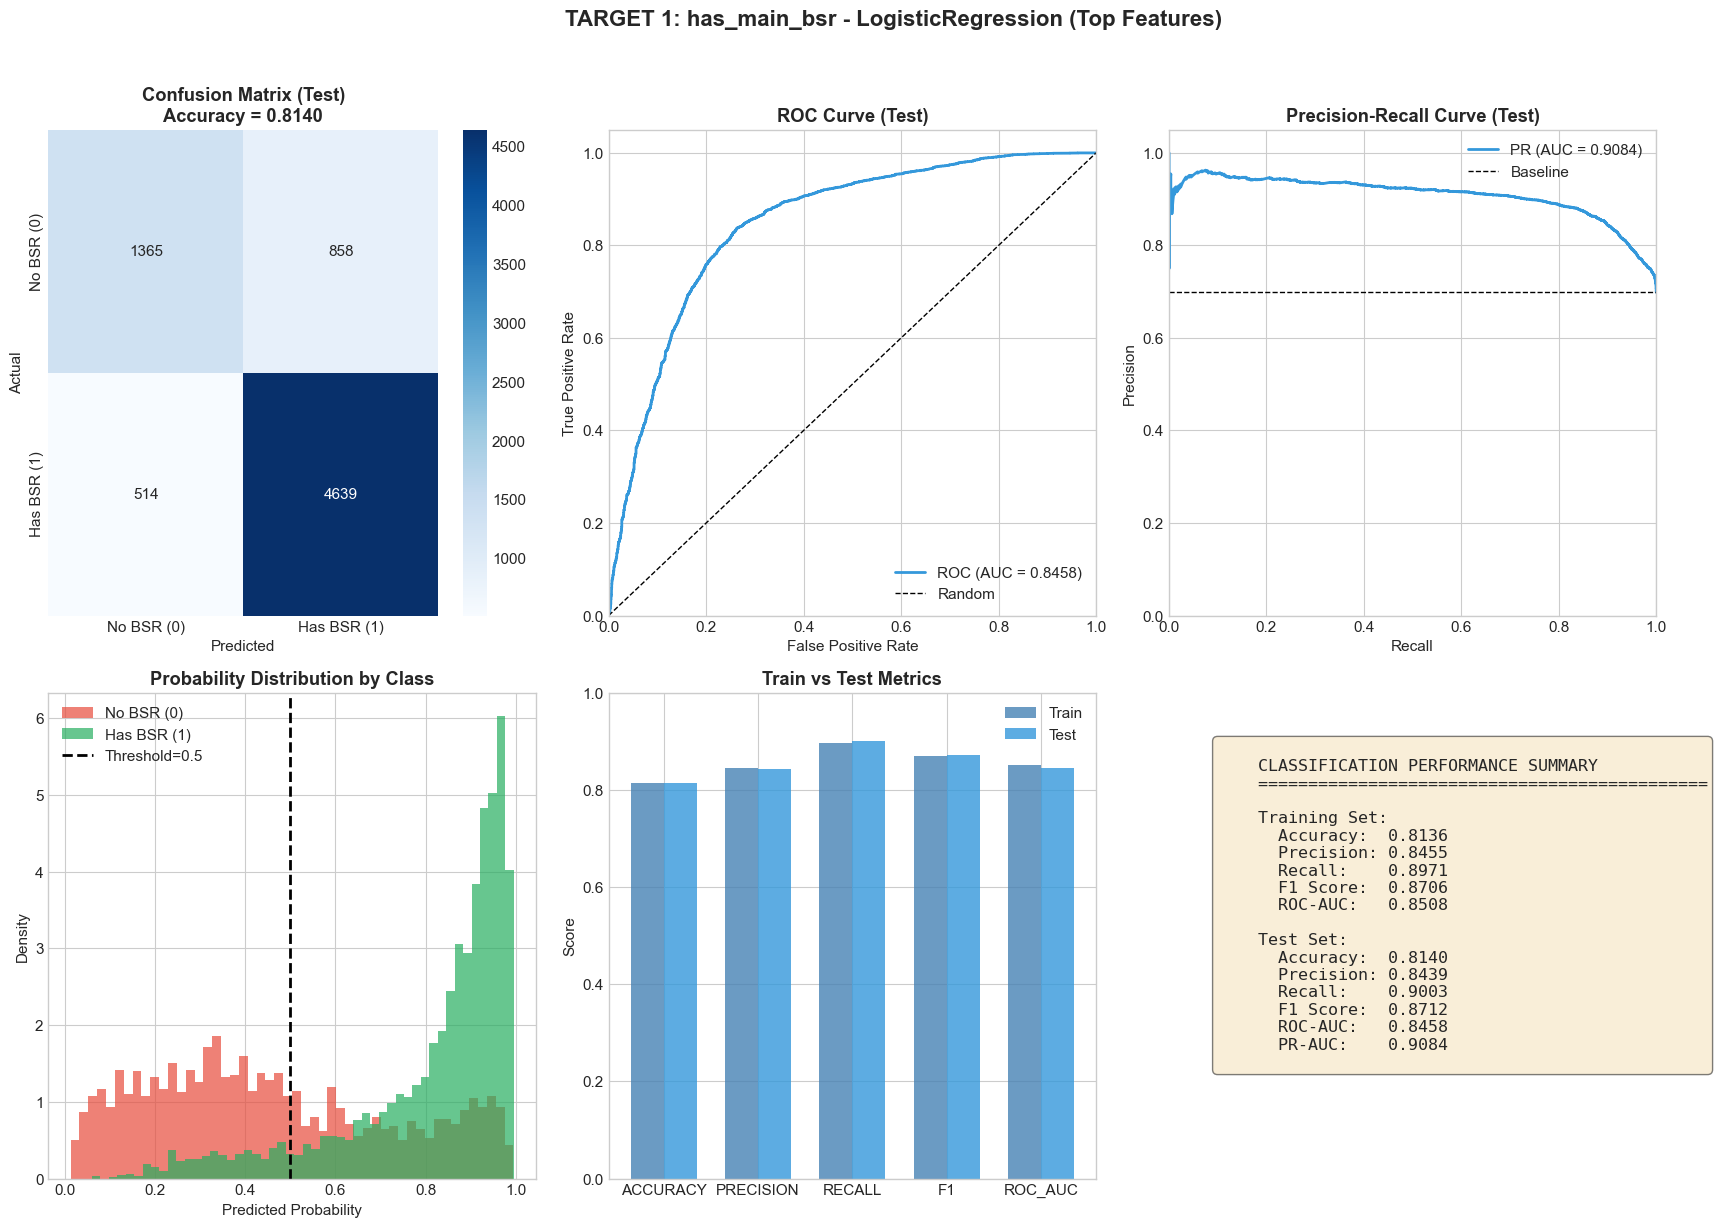

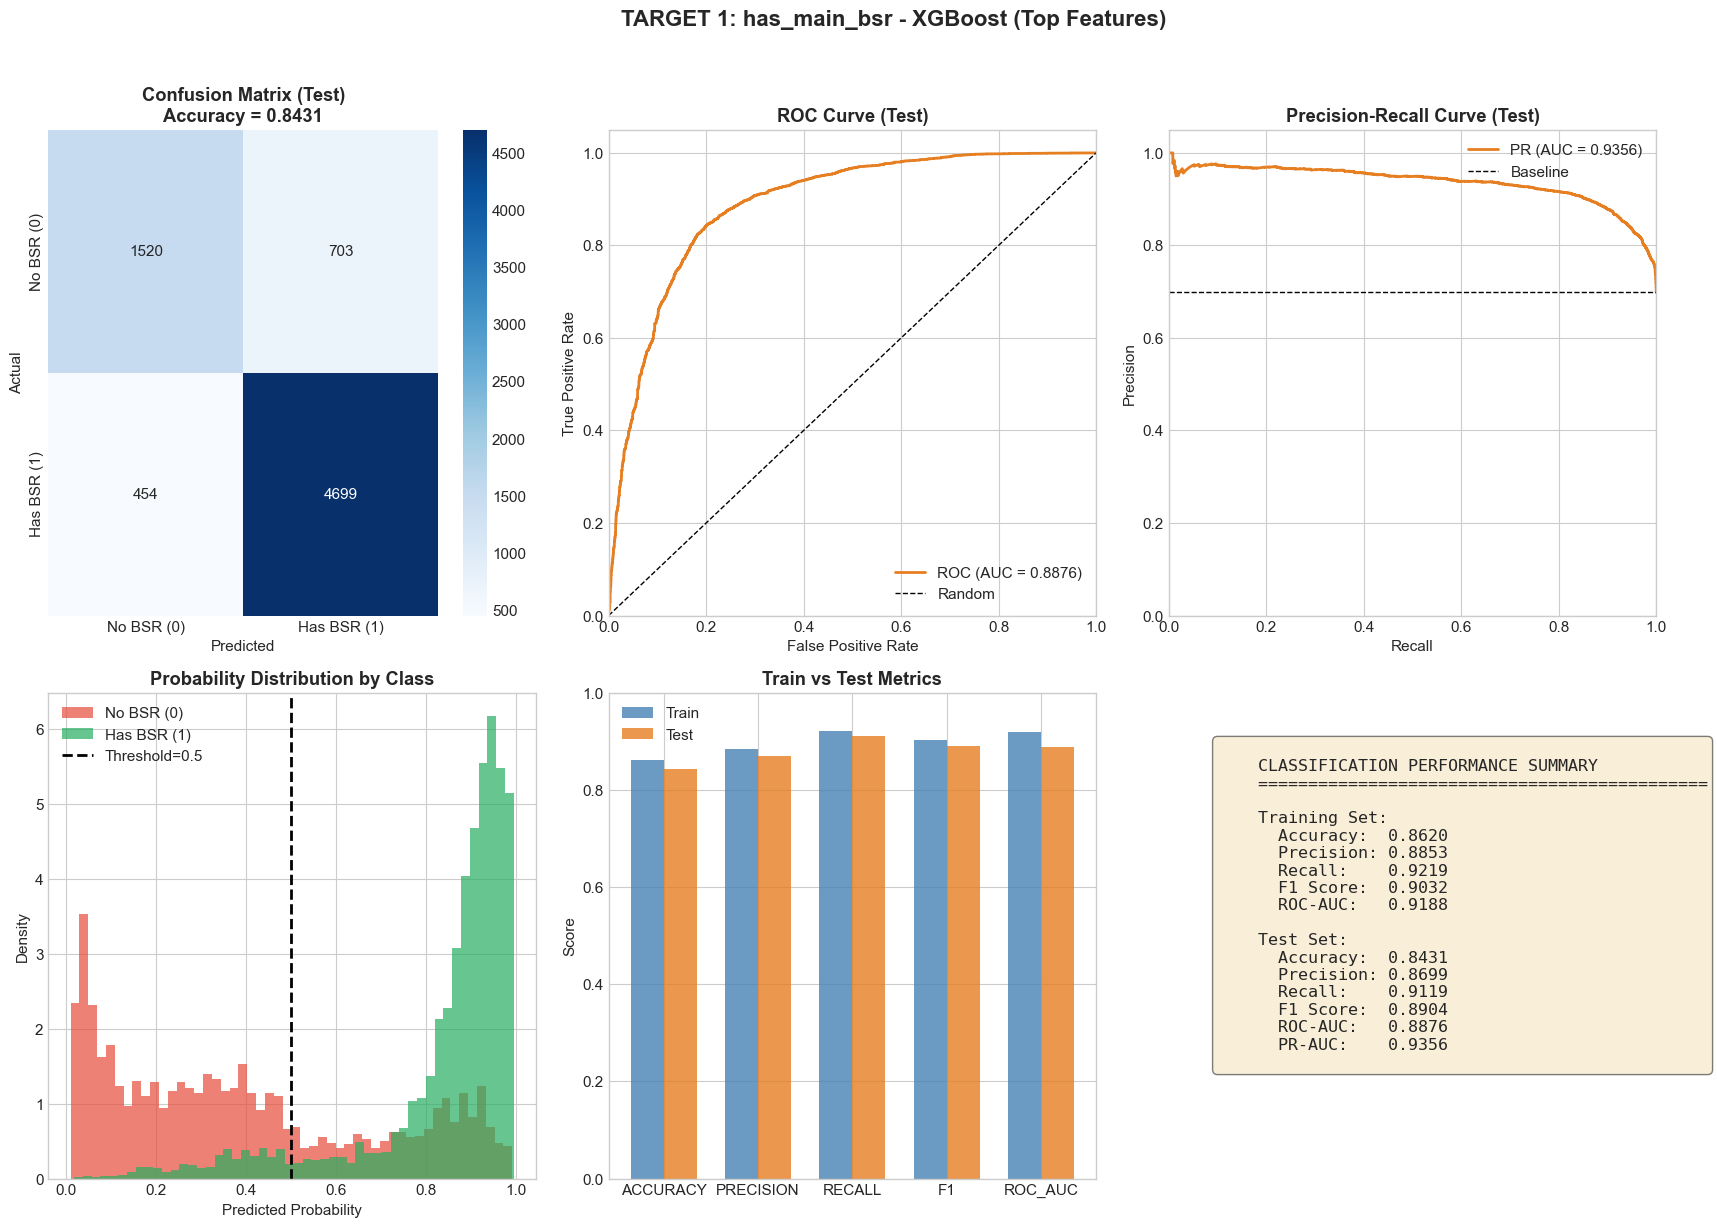

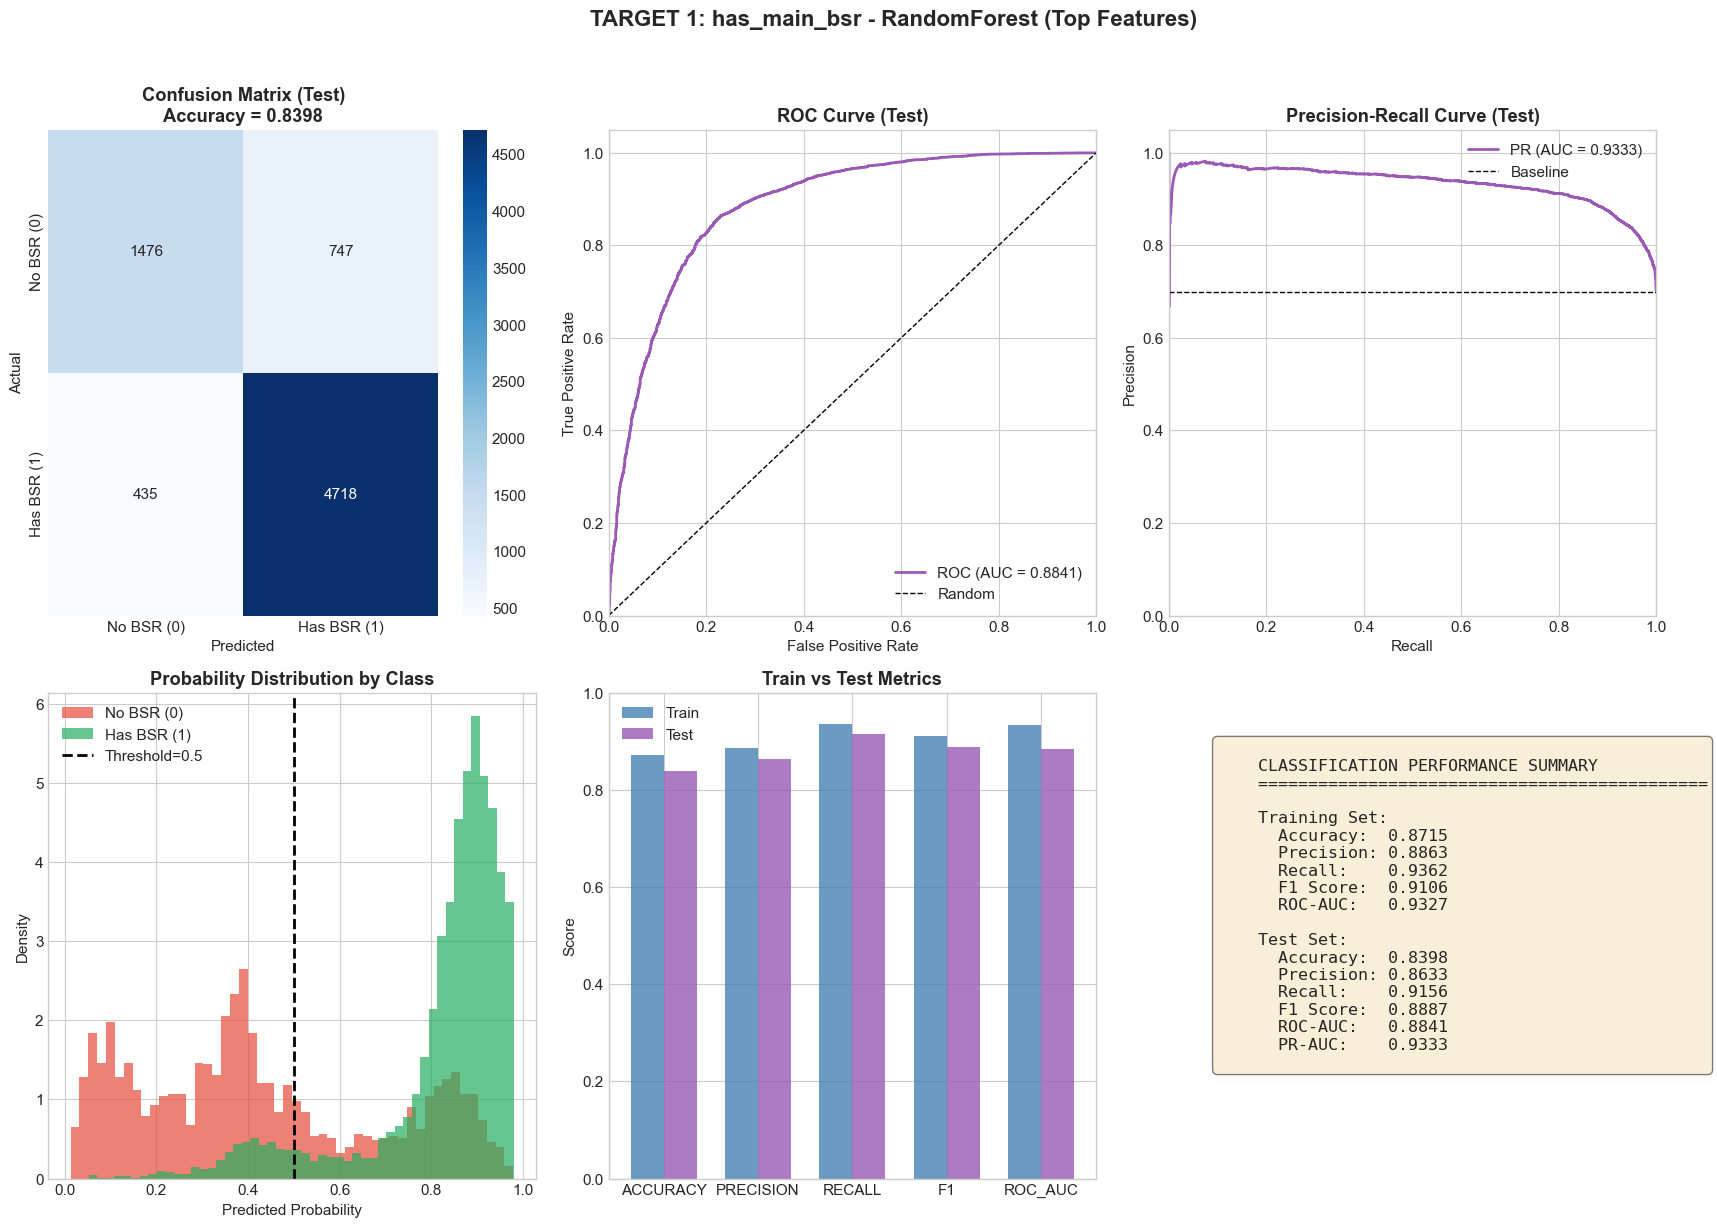

In [7]:
# Visualize results for has_main_bsr - Top Features (All Models)
for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
    plot_classification_results(
        data_main_top['y_train'], data_main_top['y_test'],
        metrics_main_top[model_name],
        f'TARGET 1: has_main_bsr - {model_name} (Top Features)',
        model_name
    )

Feature Importance - Logistic Regression (Coefficients):


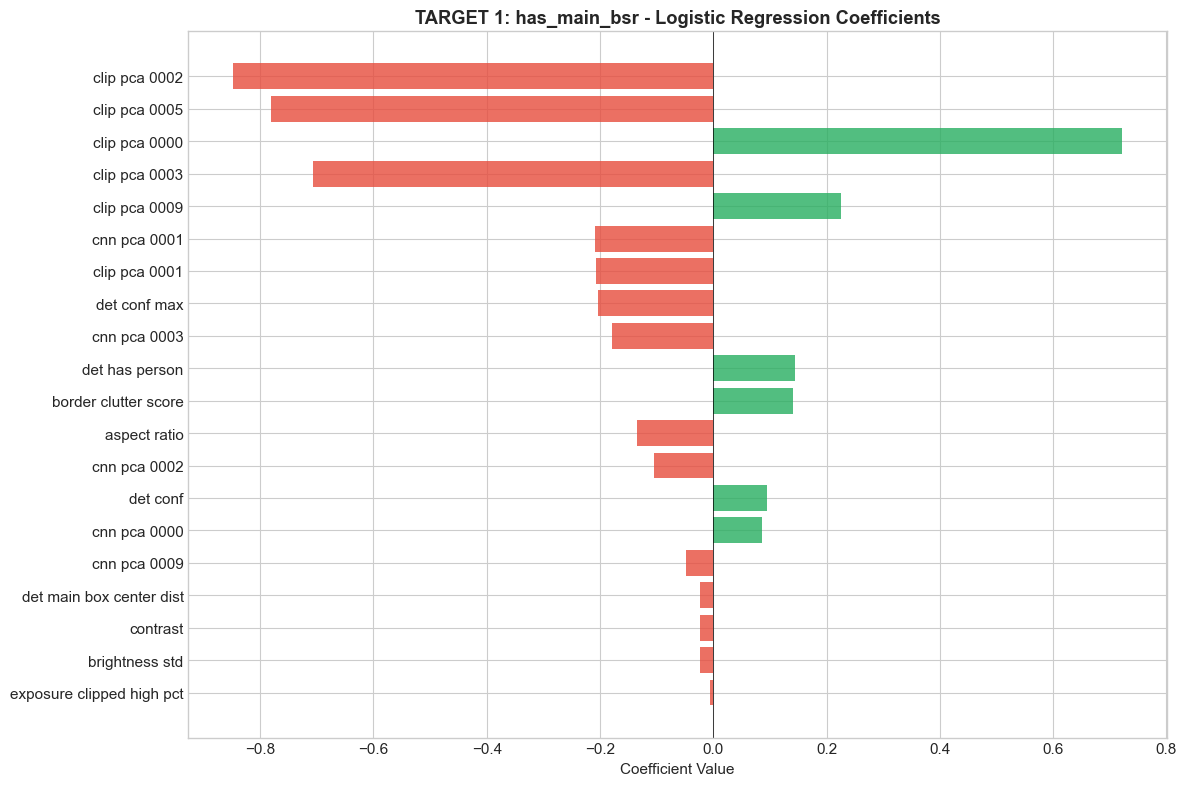


Feature Importance - XGBoost:


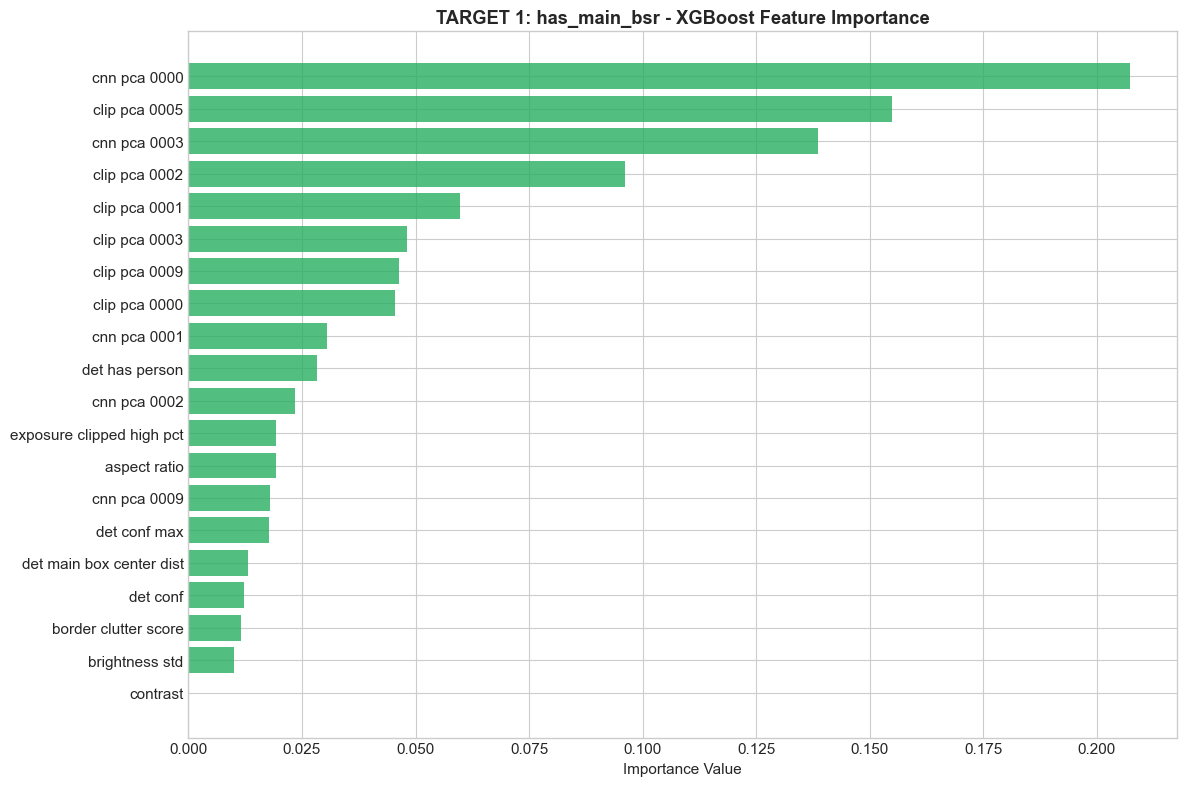


Feature Importance - Random Forest:


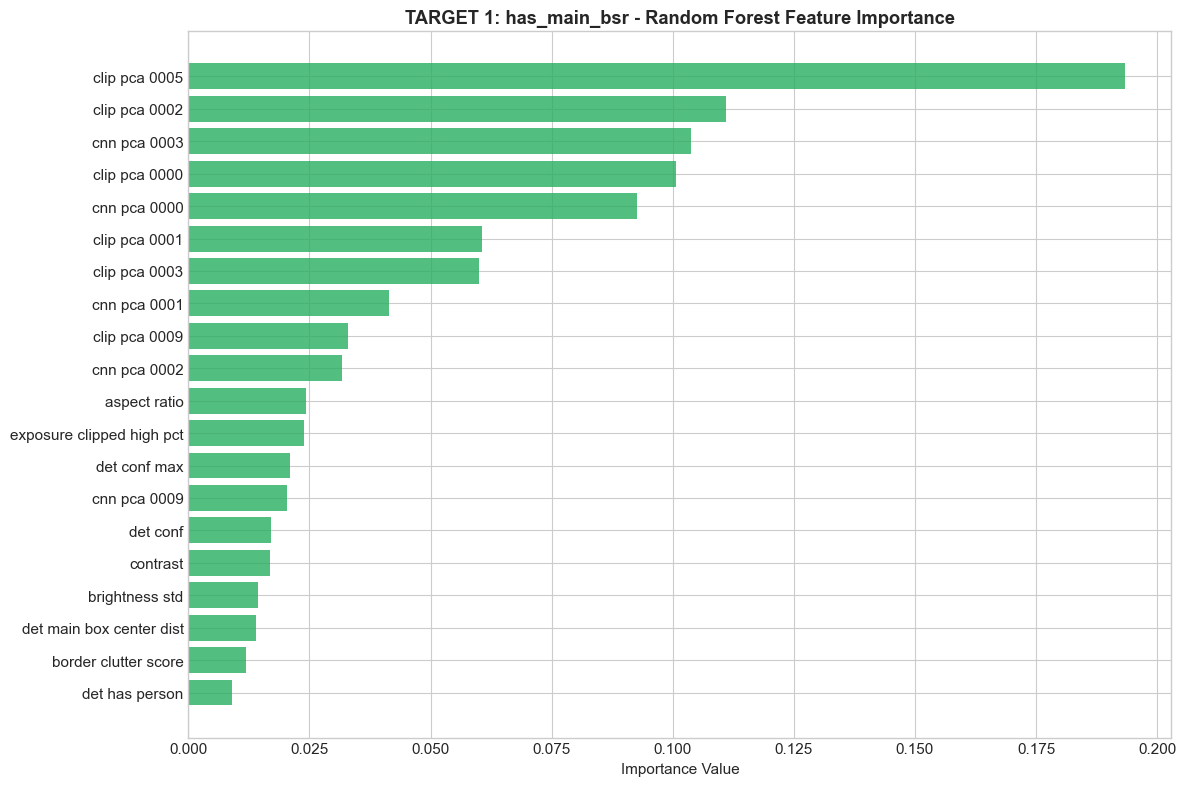

In [8]:
# Feature importance for has_main_bsr - Top Features (All Models)
print("Feature Importance - Logistic Regression (Coefficients):")
coef_main_top_lr = plot_feature_importance(
    models_main_top['LogisticRegression'], data_main_top['feature_names'],
    'TARGET 1: has_main_bsr - Logistic Regression Coefficients'
)

print("\nFeature Importance - XGBoost:")
coef_main_top_xgb = plot_feature_importance(
    models_main_top['XGBoost'], data_main_top['feature_names'],
    'TARGET 1: has_main_bsr - XGBoost Feature Importance'
)

print("\nFeature Importance - Random Forest:")
coef_main_top_rf = plot_feature_importance(
    models_main_top['RandomForest'], data_main_top['feature_names'],
    'TARGET 1: has_main_bsr - Random Forest Feature Importance'
)

In [9]:
# =============================================================================
# 6. TARGET 1: has_main_bsr - ALL FEATURES MODELS
# =============================================================================

print("="*70)
print("TARGET 1: has_main_bsr CLASSIFICATION - ALL FEATURES")
print("="*70)

# Prepare data with all features (excluding other target)
# Remove lowest_bsr columns from features
all_features_main = [f for f in all_feature_cols 
                     if 'lowest_bsr' not in f.lower() and 'has_' not in f.lower()]

data_main_all = prepare_data(df, 'has_main_bsr', all_features_main)

print(f"\nSamples: {data_main_all['n_samples']:,}")
print(f"Features: {len(data_main_all['feature_names'])}")
print(f"Train size: {len(data_main_all['y_train']):,}")
print(f"Test size: {len(data_main_all['y_test']):,}")

# Store all models and metrics
models_main_all = {}
metrics_main_all = {}

# 1. Logistic Regression (L2 Regularized)
print("\n" + "-"*50)
print("Model 1: Logistic Regression (L2 Regularized)")
print("-"*50)
lr_model_all = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model_all.fit(data_main_all['X_train'], data_main_all['y_train'])
models_main_all['LogisticRegression'] = lr_model_all
metrics_main_all['LogisticRegression'] = evaluate_classifier(
    lr_model_all, data_main_all['X_train'], data_main_all['X_test'],
    data_main_all['y_train'], data_main_all['y_test']
)
print(f"Test Accuracy: {metrics_main_all['LogisticRegression']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_all['LogisticRegression']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_all['LogisticRegression']['test_f1']:.4f}")

# 2. XGBoost Classifier
print("\n" + "-"*50)
print("Model 2: XGBoost Classifier")
print("-"*50)
xgb_model_all = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model_all.fit(data_main_all['X_train'], data_main_all['y_train'])
models_main_all['XGBoost'] = xgb_model_all
metrics_main_all['XGBoost'] = evaluate_classifier(
    xgb_model_all, data_main_all['X_train'], data_main_all['X_test'],
    data_main_all['y_train'], data_main_all['y_test']
)
print(f"Test Accuracy: {metrics_main_all['XGBoost']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_all['XGBoost']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_all['XGBoost']['test_f1']:.4f}")

# 3. Random Forest Classifier
print("\n" + "-"*50)
print("Model 3: Random Forest Classifier")
print("-"*50)
rf_model_all = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model_all.fit(data_main_all['X_train'], data_main_all['y_train'])
models_main_all['RandomForest'] = rf_model_all
metrics_main_all['RandomForest'] = evaluate_classifier(
    rf_model_all, data_main_all['X_train'], data_main_all['X_test'],
    data_main_all['y_train'], data_main_all['y_test']
)
print(f"Test Accuracy: {metrics_main_all['RandomForest']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_main_all['RandomForest']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_main_all['RandomForest']['test_f1']:.4f}")

TARGET 1: has_main_bsr CLASSIFICATION - ALL FEATURES
  Kept 7561 features after removing high-missing columns
  Final samples after cleaning: 36879
  Class distribution: 0=11,113 | 1=25,766 (69.9% positive)

Samples: 36,879
Features: 7561
Train size: 29,503
Test size: 7,376

--------------------------------------------------
Model 1: Logistic Regression (L2 Regularized)
--------------------------------------------------
Test Accuracy: 0.8537
Test ROC-AUC:  0.8969
Test F1:       0.8972

--------------------------------------------------
Model 2: XGBoost Classifier
--------------------------------------------------
Test Accuracy: 0.8673
Test ROC-AUC:  0.9121
Test F1:       0.9072

--------------------------------------------------
Model 3: Random Forest Classifier
--------------------------------------------------
Test Accuracy: 0.8431
Test ROC-AUC:  0.8958
Test F1:       0.8936


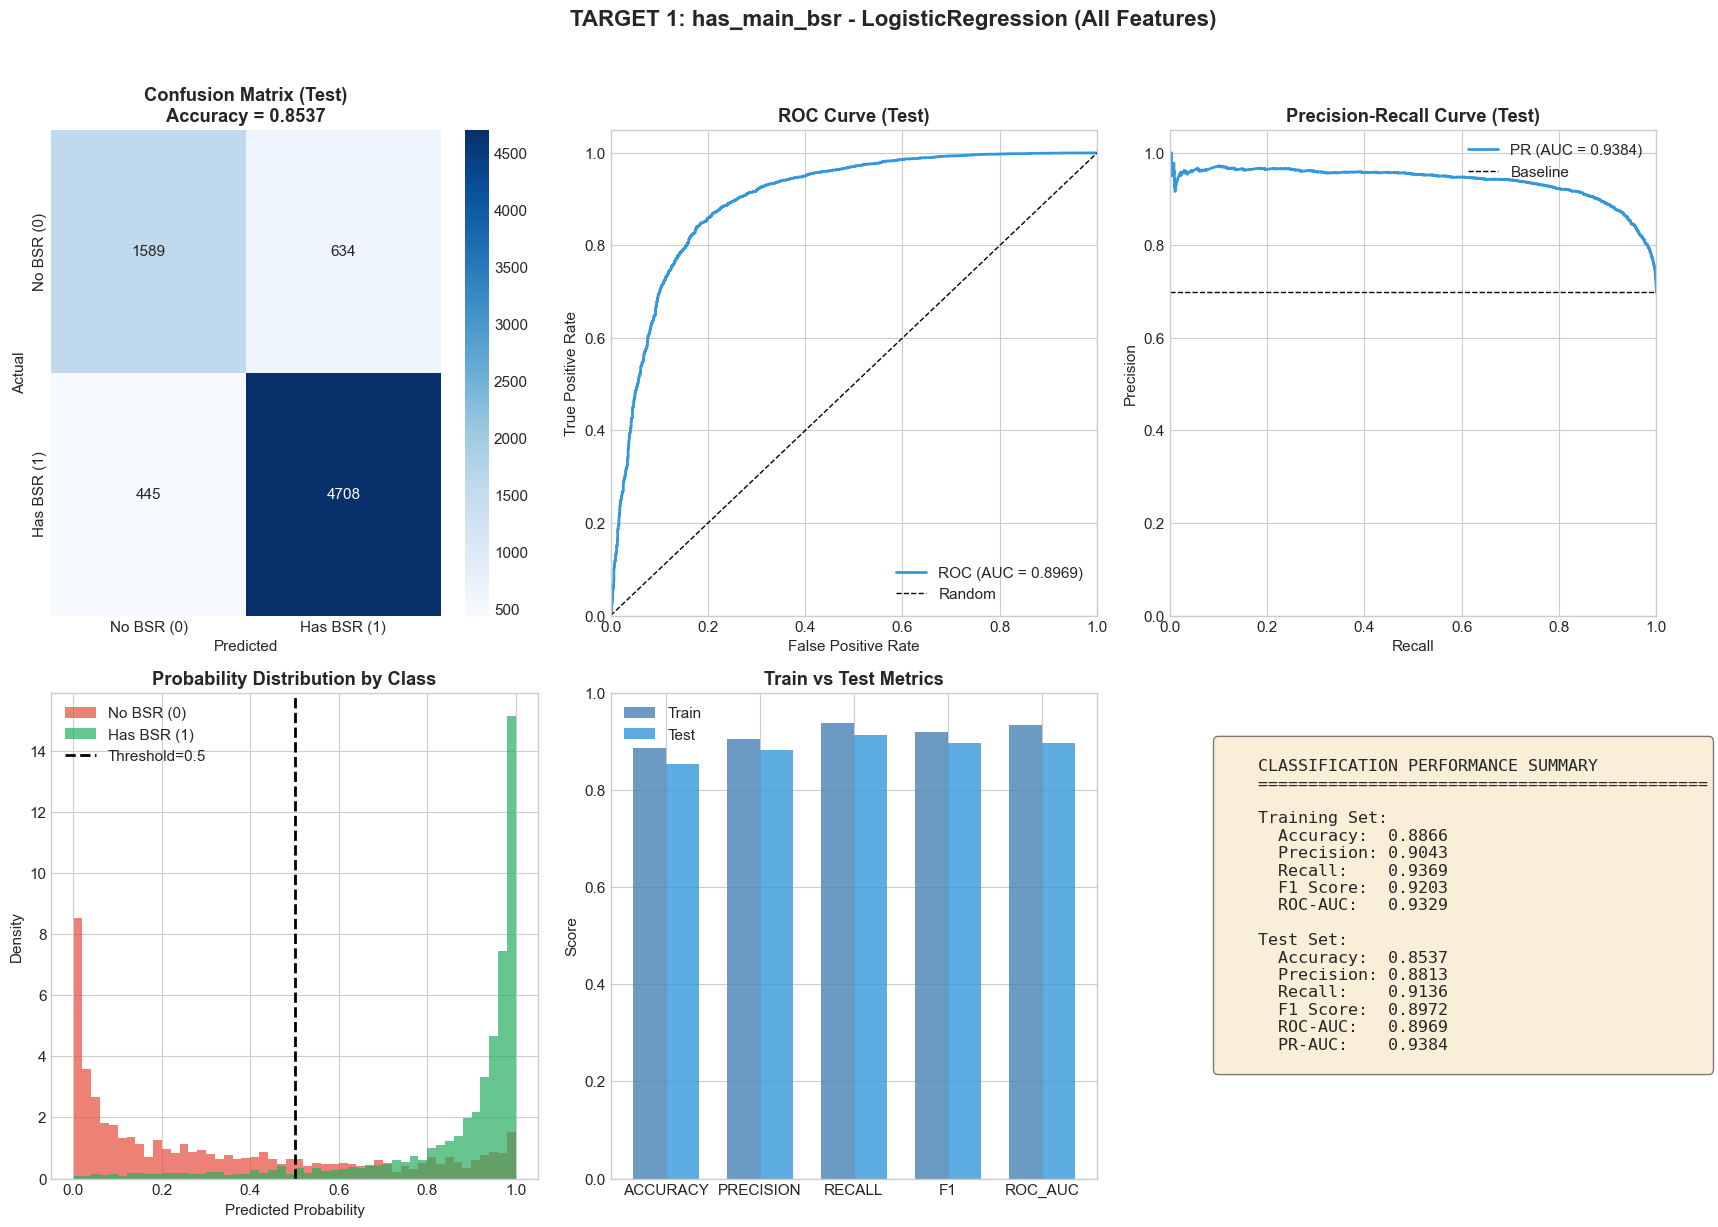

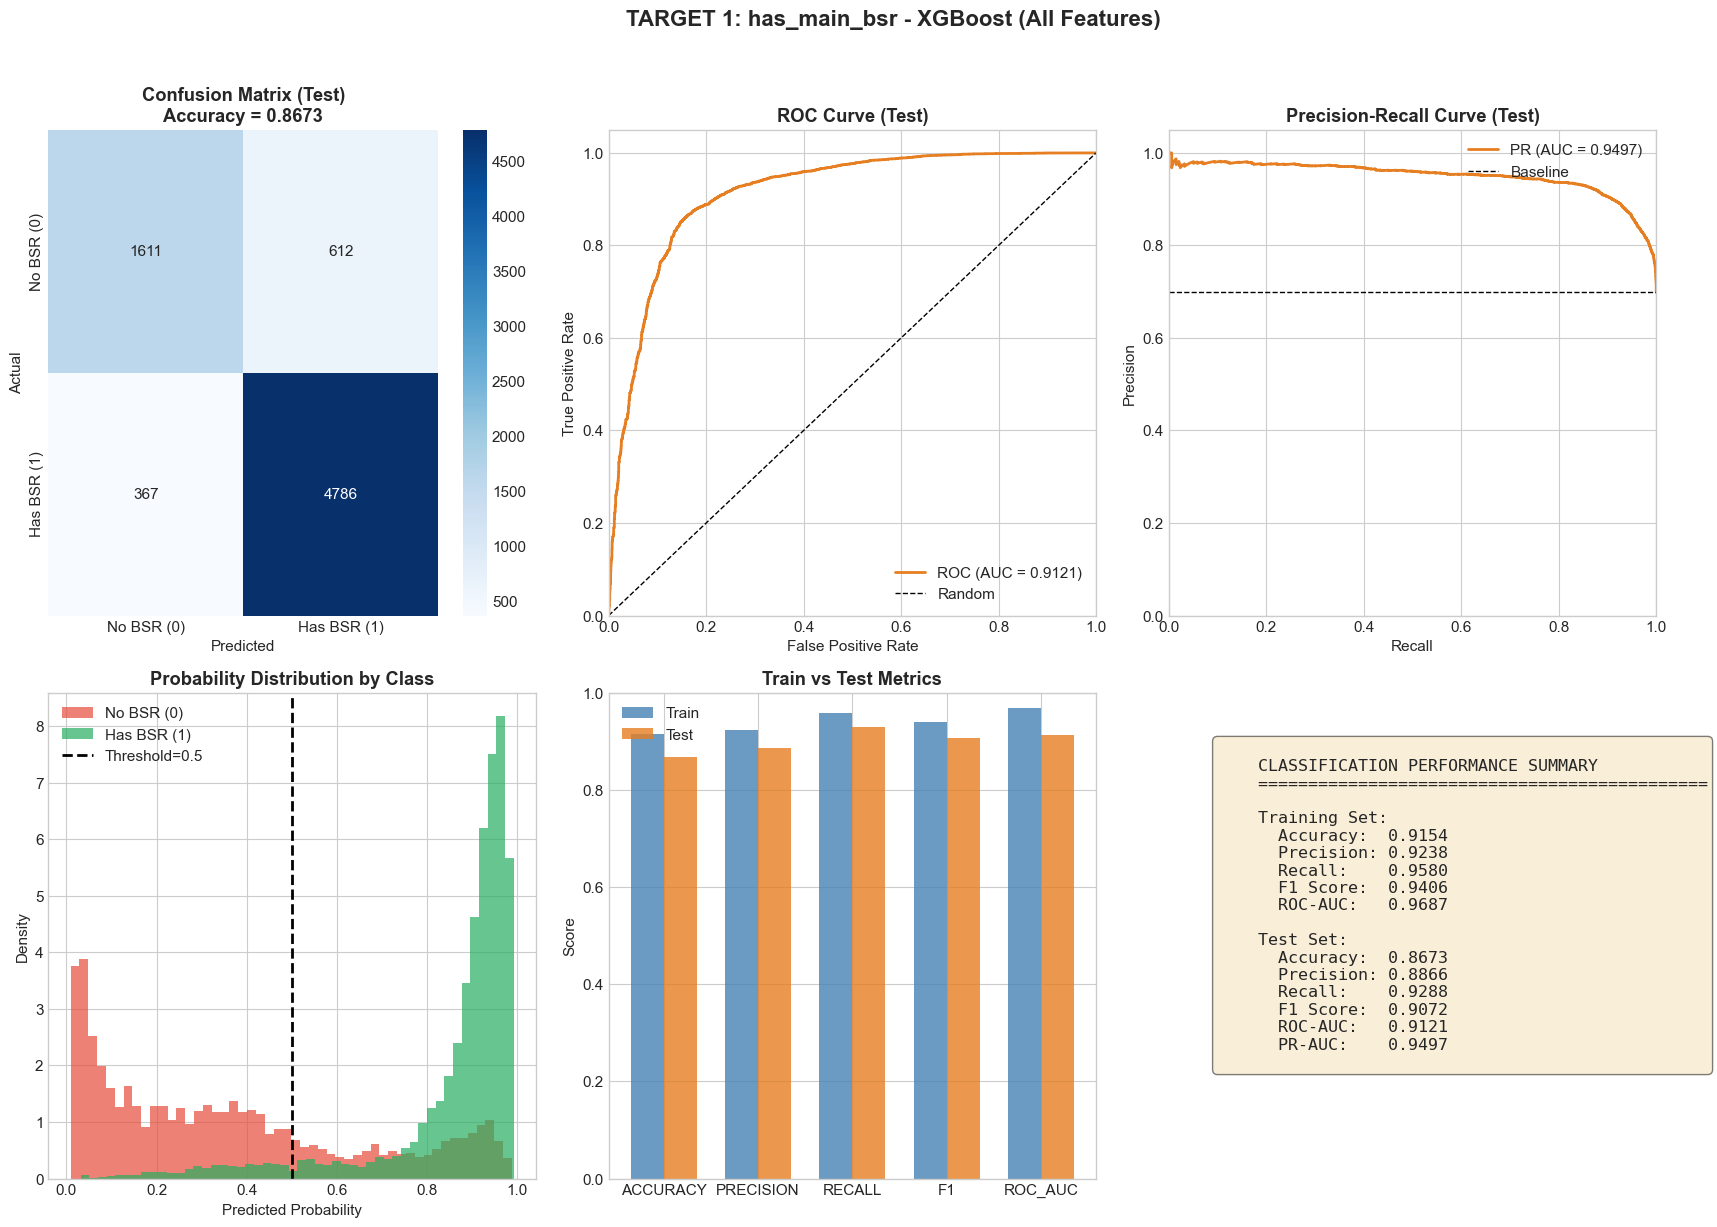

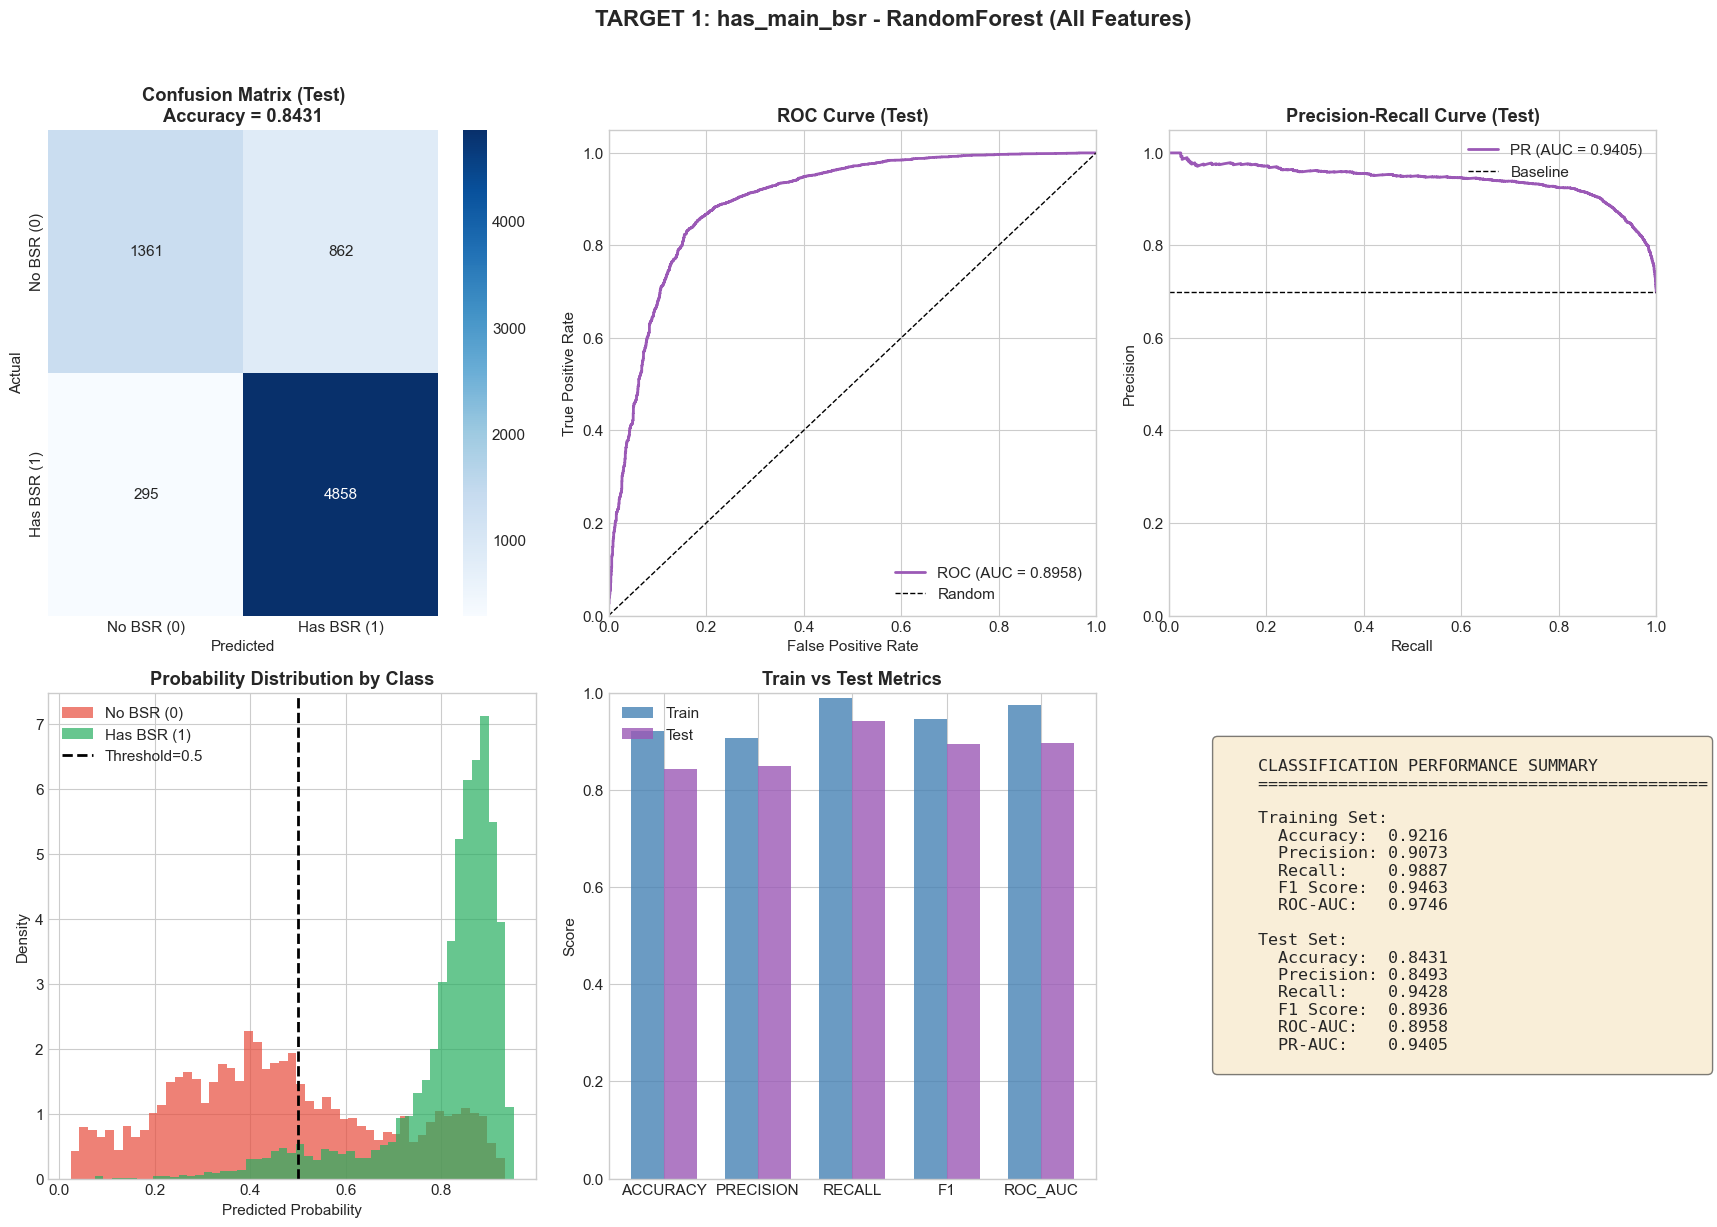

In [10]:
# Visualize results for has_main_bsr - All Features (All Models)
for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
    plot_classification_results(
        data_main_all['y_train'], data_main_all['y_test'],
        metrics_main_all[model_name],
        f'TARGET 1: has_main_bsr - {model_name} (All Features)',
        model_name
    )

Feature Importance - XGBoost (All Features):


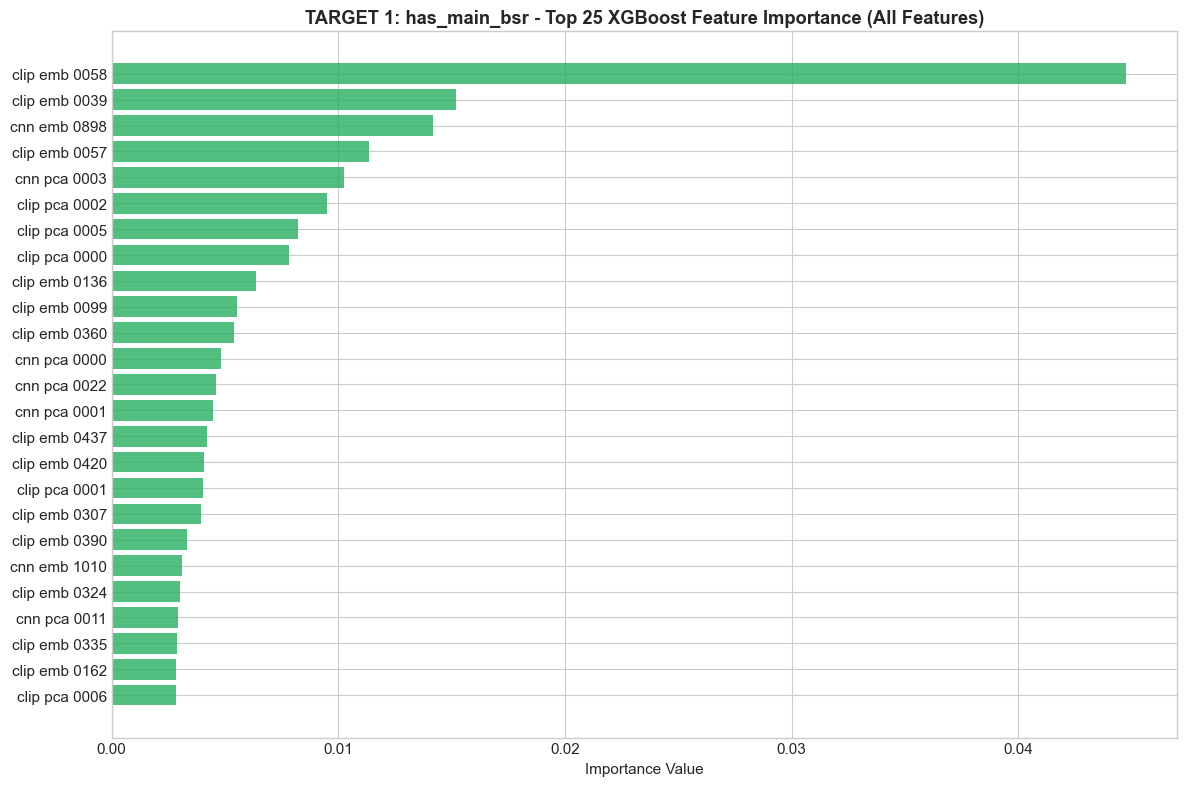

In [11]:
# Feature importance for has_main_bsr - All Features (top 25)
print("Feature Importance - XGBoost (All Features):")
coef_main_all_xgb = plot_feature_importance(
    models_main_all['XGBoost'], data_main_all['feature_names'],
    'TARGET 1: has_main_bsr - Top 25 XGBoost Feature Importance (All Features)',
    top_n=25
)

---
## TARGET 2: has_lowest_bsr Classification
Predicting whether a product has any BSR rank in any category (binary: 0=No, 1=Yes).

**Note**: This is very similar to TARGET 1 since both measure BSR presence.

In [12]:
# =============================================================================
# 7. TARGET 2: has_lowest_bsr - TOP FEATURES MODELS
# =============================================================================

print("="*70)
print("TARGET 2: has_lowest_bsr CLASSIFICATION - TOP FEATURES")
print("="*70)

# Prepare data with top features
data_lowest_top = prepare_data(df, 'has_lowest_bsr', top_features)

print(f"\nSamples: {data_lowest_top['n_samples']:,}")
print(f"Features: {len(data_lowest_top['feature_names'])}")
print(f"Train size: {len(data_lowest_top['y_train']):,}")
print(f"Test size: {len(data_lowest_top['y_test']):,}")

# Store all models and metrics
models_lowest_top = {}
metrics_lowest_top = {}

# 1. Logistic Regression (L2 Regularized)
print("\n" + "-"*50)
print("Model 1: Logistic Regression (L2 Regularized)")
print("-"*50)
lr_model_l = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model_l.fit(data_lowest_top['X_train'], data_lowest_top['y_train'])
models_lowest_top['LogisticRegression'] = lr_model_l
metrics_lowest_top['LogisticRegression'] = evaluate_classifier(
    lr_model_l, data_lowest_top['X_train'], data_lowest_top['X_test'],
    data_lowest_top['y_train'], data_lowest_top['y_test']
)
print(f"Test Accuracy: {metrics_lowest_top['LogisticRegression']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_top['LogisticRegression']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_top['LogisticRegression']['test_f1']:.4f}")

# 2. XGBoost Classifier
print("\n" + "-"*50)
print("Model 2: XGBoost Classifier")
print("-"*50)
xgb_model_l = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model_l.fit(data_lowest_top['X_train'], data_lowest_top['y_train'])
models_lowest_top['XGBoost'] = xgb_model_l
metrics_lowest_top['XGBoost'] = evaluate_classifier(
    xgb_model_l, data_lowest_top['X_train'], data_lowest_top['X_test'],
    data_lowest_top['y_train'], data_lowest_top['y_test']
)
print(f"Test Accuracy: {metrics_lowest_top['XGBoost']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_top['XGBoost']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_top['XGBoost']['test_f1']:.4f}")

# 3. Random Forest Classifier
print("\n" + "-"*50)
print("Model 3: Random Forest Classifier")
print("-"*50)
rf_model_l = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model_l.fit(data_lowest_top['X_train'], data_lowest_top['y_train'])
models_lowest_top['RandomForest'] = rf_model_l
metrics_lowest_top['RandomForest'] = evaluate_classifier(
    rf_model_l, data_lowest_top['X_train'], data_lowest_top['X_test'],
    data_lowest_top['y_train'], data_lowest_top['y_test']
)
print(f"Test Accuracy: {metrics_lowest_top['RandomForest']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_top['RandomForest']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_top['RandomForest']['test_f1']:.4f}")

TARGET 2: has_lowest_bsr CLASSIFICATION - TOP FEATURES
  Kept 20 features after removing high-missing columns
  Final samples after cleaning: 36879
  Class distribution: 0=11,113 | 1=25,766 (69.9% positive)

Samples: 36,879
Features: 20
Train size: 29,503
Test size: 7,376

--------------------------------------------------
Model 1: Logistic Regression (L2 Regularized)
--------------------------------------------------
Test Accuracy: 0.8140
Test ROC-AUC:  0.8458
Test F1:       0.8712

--------------------------------------------------
Model 2: XGBoost Classifier
--------------------------------------------------
Test Accuracy: 0.8431
Test ROC-AUC:  0.8876
Test F1:       0.8904

--------------------------------------------------
Model 3: Random Forest Classifier
--------------------------------------------------
Test Accuracy: 0.8398
Test ROC-AUC:  0.8841
Test F1:       0.8887


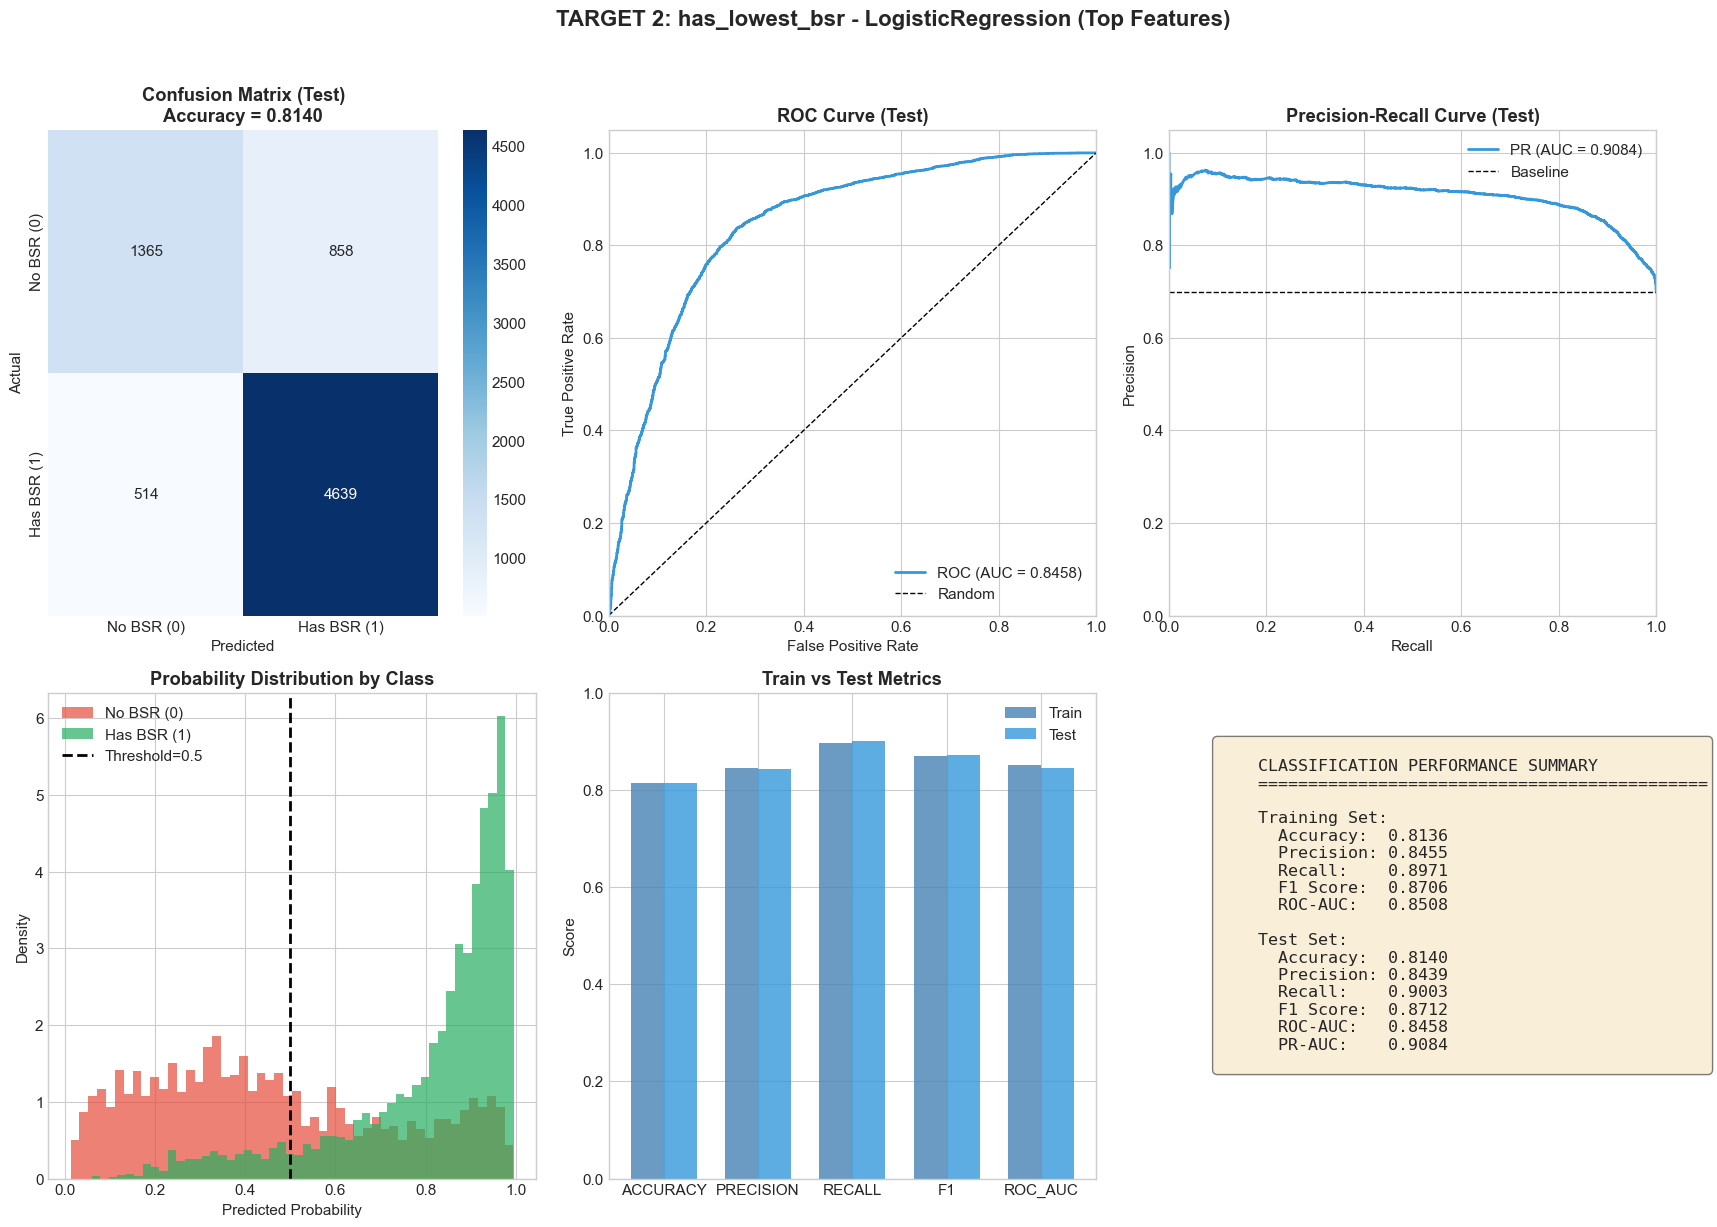

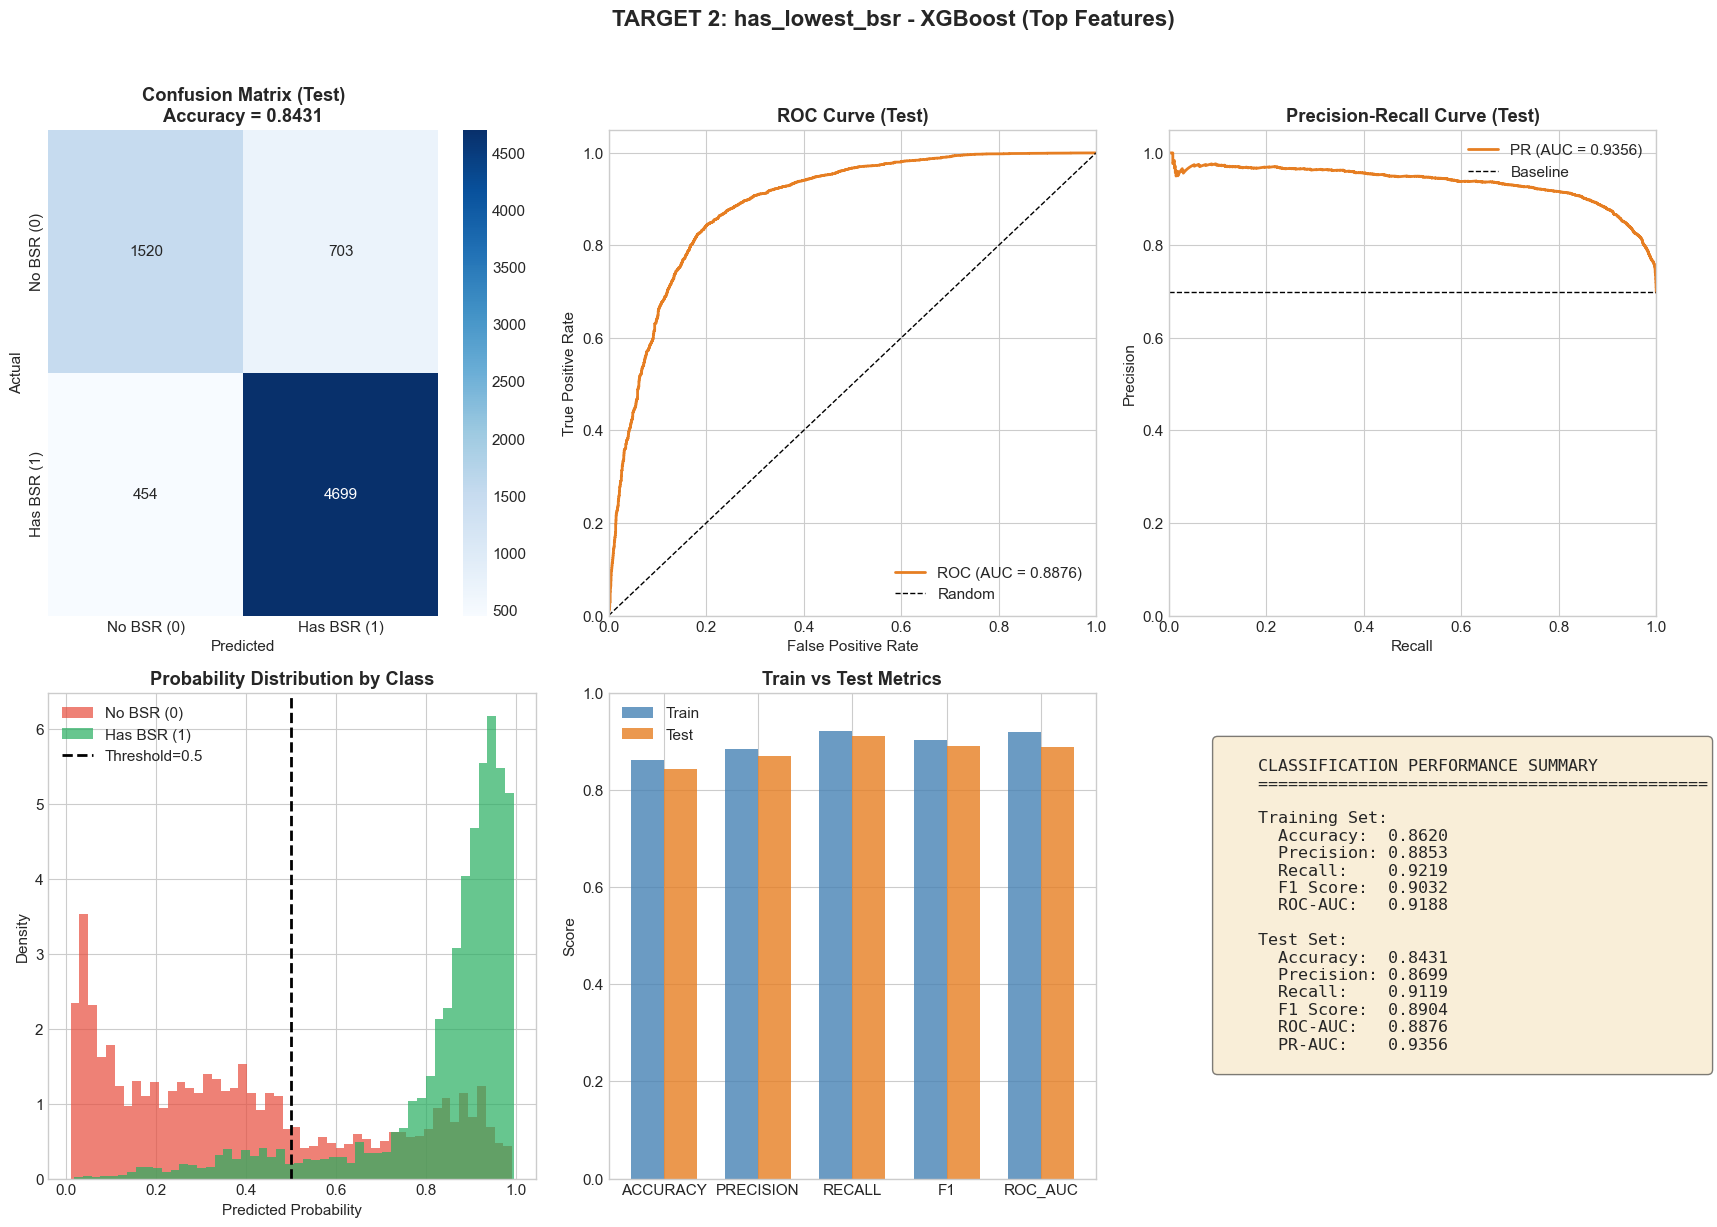

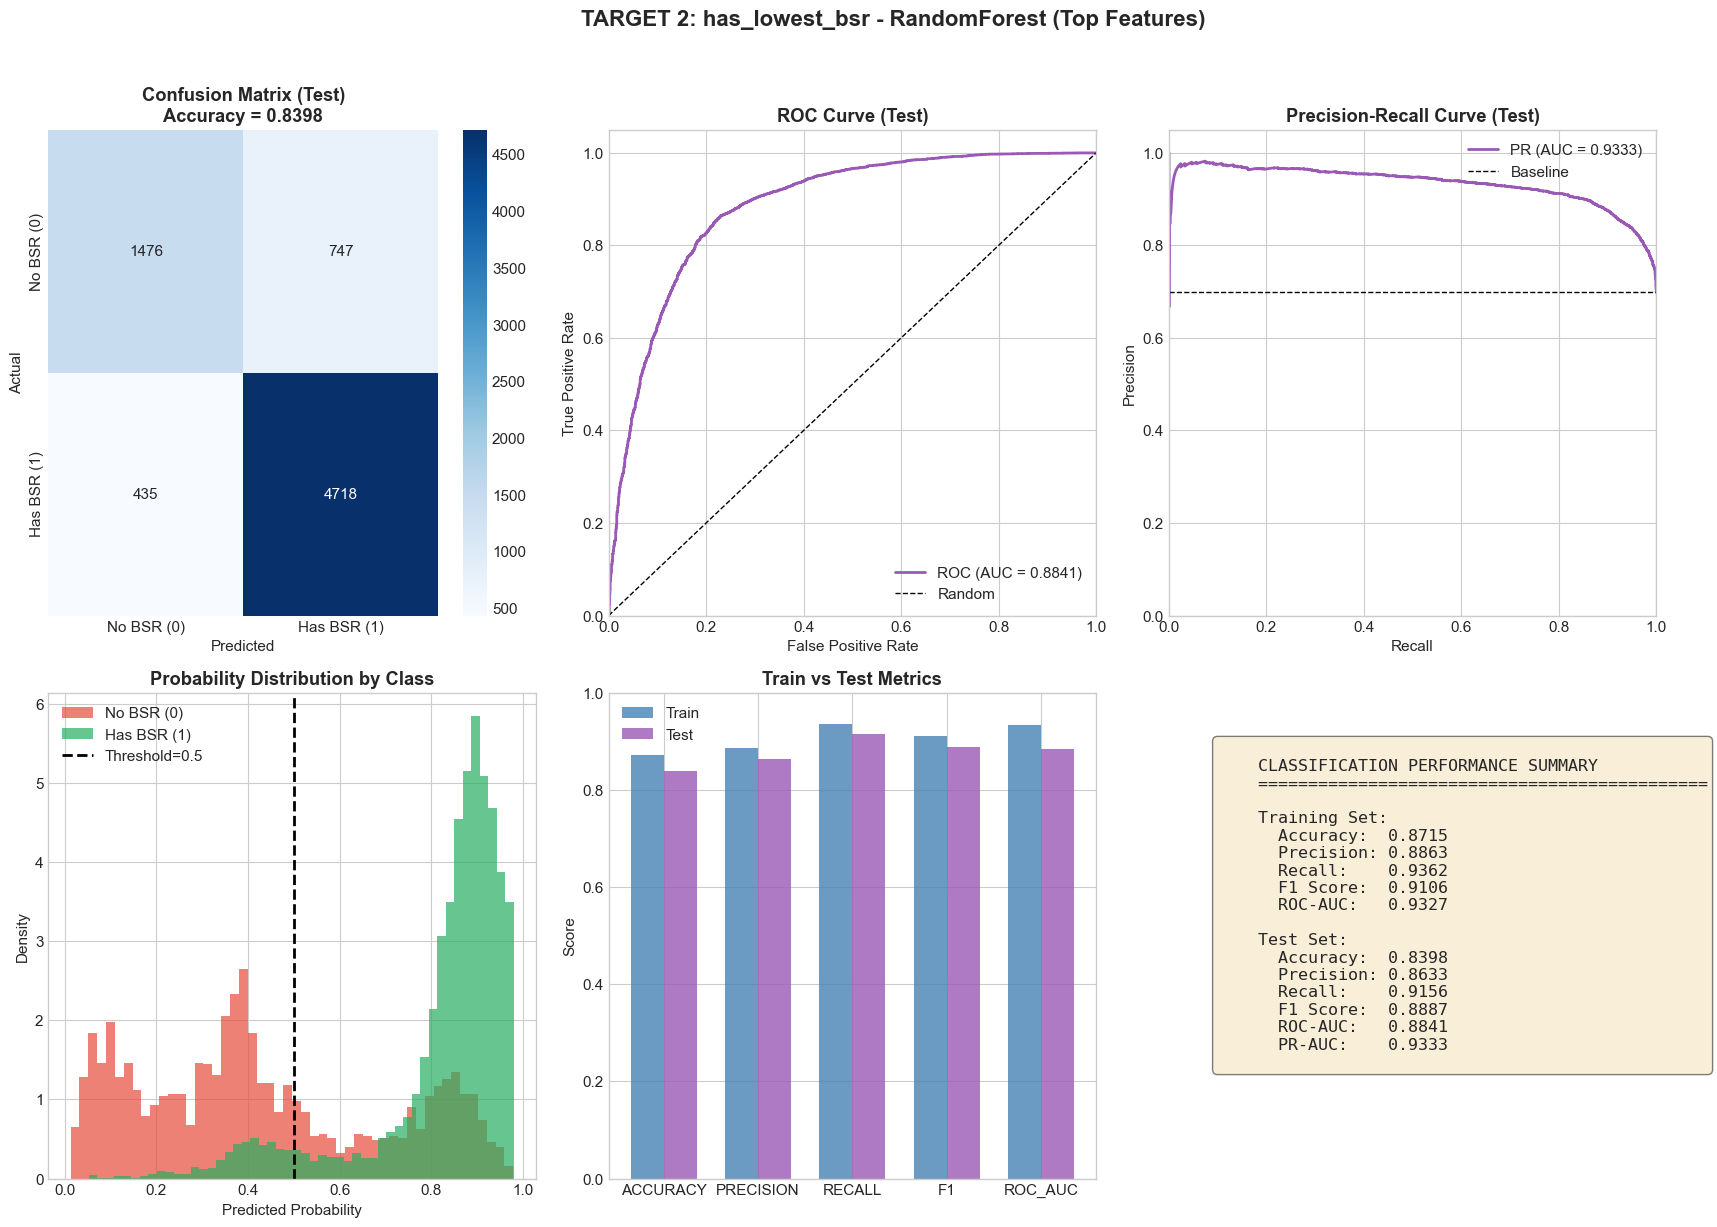

In [13]:
# Visualize results for has_lowest_bsr - Top Features (All Models)
for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
    plot_classification_results(
        data_lowest_top['y_train'], data_lowest_top['y_test'],
        metrics_lowest_top[model_name],
        f'TARGET 2: has_lowest_bsr - {model_name} (Top Features)',
        model_name
    )

Feature Importance - XGBoost:


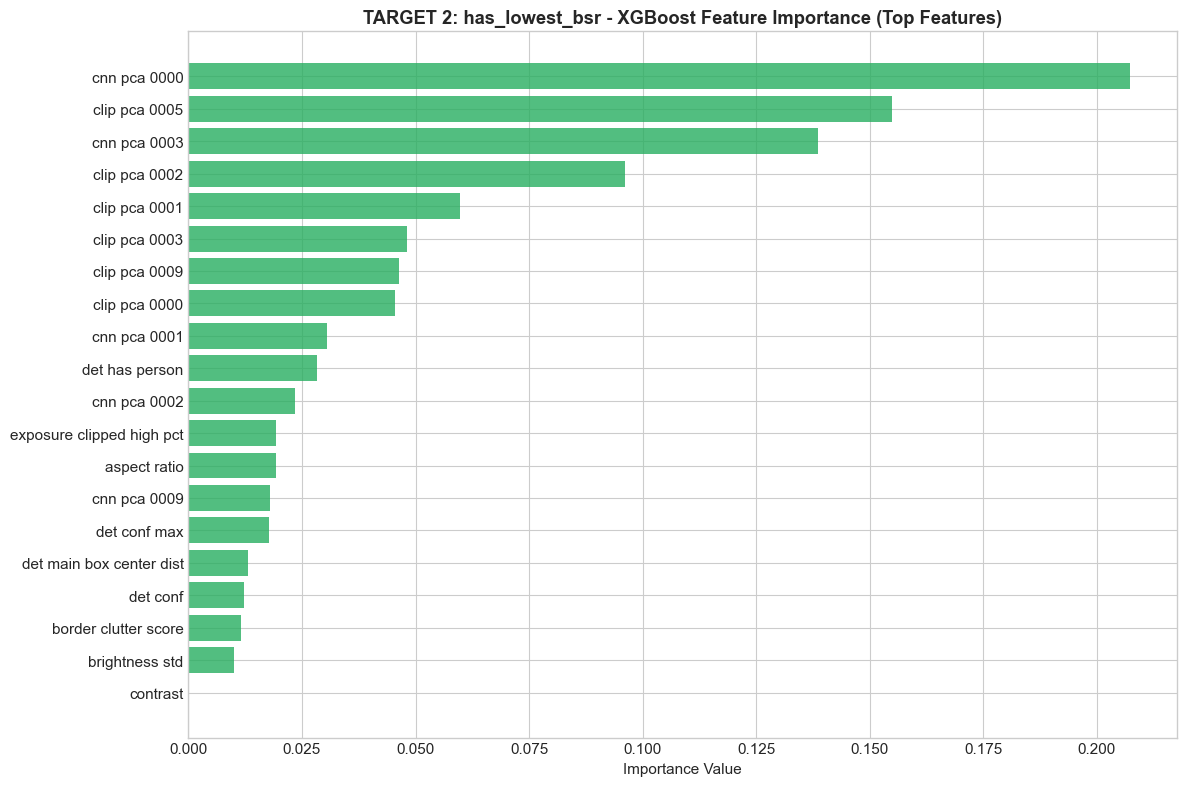

In [23]:
# Feature importance for has_lowest_bsr - Top Features (All Models)
print("Feature Importance - XGBoost:")
coef_lowest_top_xgb = plot_feature_importance(
    models_lowest_top['XGBoost'], data_lowest_top['feature_names'],
    'TARGET 2: has_lowest_bsr - XGBoost Feature Importance (Top Features)'
)

In [14]:
# =============================================================================
# 8. TARGET 2: has_lowest_bsr - ALL FEATURES MODELS
# =============================================================================

print("="*70)
print("TARGET 2: has_lowest_bsr CLASSIFICATION - ALL FEATURES")
print("="*70)

# Prepare data with all features (excluding other target)
# Remove main_bsr columns from features
all_features_lowest = [f for f in all_feature_cols 
                       if 'main_bsr' not in f.lower() and 'has_' not in f.lower()]

data_lowest_all = prepare_data(df, 'has_lowest_bsr', all_features_lowest)

print(f"\nSamples: {data_lowest_all['n_samples']:,}")
print(f"Features: {len(data_lowest_all['feature_names'])}")
print(f"Train size: {len(data_lowest_all['y_train']):,}")
print(f"Test size: {len(data_lowest_all['y_test']):,}")

# Store all models and metrics
models_lowest_all = {}
metrics_lowest_all = {}

# 1. Logistic Regression (L2 Regularized)
print("\n" + "-"*50)
print("Model 1: Logistic Regression (L2 Regularized)")
print("-"*50)
lr_model_la = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_model_la.fit(data_lowest_all['X_train'], data_lowest_all['y_train'])
models_lowest_all['LogisticRegression'] = lr_model_la
metrics_lowest_all['LogisticRegression'] = evaluate_classifier(
    lr_model_la, data_lowest_all['X_train'], data_lowest_all['X_test'],
    data_lowest_all['y_train'], data_lowest_all['y_test']
)
print(f"Test Accuracy: {metrics_lowest_all['LogisticRegression']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_all['LogisticRegression']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_all['LogisticRegression']['test_f1']:.4f}")

# 2. XGBoost Classifier
print("\n" + "-"*50)
print("Model 2: XGBoost Classifier")
print("-"*50)
xgb_model_la = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model_la.fit(data_lowest_all['X_train'], data_lowest_all['y_train'])
models_lowest_all['XGBoost'] = xgb_model_la
metrics_lowest_all['XGBoost'] = evaluate_classifier(
    xgb_model_la, data_lowest_all['X_train'], data_lowest_all['X_test'],
    data_lowest_all['y_train'], data_lowest_all['y_test']
)
print(f"Test Accuracy: {metrics_lowest_all['XGBoost']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_all['XGBoost']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_all['XGBoost']['test_f1']:.4f}")

# 3. Random Forest Classifier
print("\n" + "-"*50)
print("Model 3: Random Forest Classifier")
print("-"*50)
rf_model_la = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model_la.fit(data_lowest_all['X_train'], data_lowest_all['y_train'])
models_lowest_all['RandomForest'] = rf_model_la
metrics_lowest_all['RandomForest'] = evaluate_classifier(
    rf_model_la, data_lowest_all['X_train'], data_lowest_all['X_test'],
    data_lowest_all['y_train'], data_lowest_all['y_test']
)
print(f"Test Accuracy: {metrics_lowest_all['RandomForest']['test_accuracy']:.4f}")
print(f"Test ROC-AUC:  {metrics_lowest_all['RandomForest']['test_roc_auc']:.4f}")
print(f"Test F1:       {metrics_lowest_all['RandomForest']['test_f1']:.4f}")

TARGET 2: has_lowest_bsr CLASSIFICATION - ALL FEATURES
  Kept 7561 features after removing high-missing columns
  Final samples after cleaning: 36879
  Class distribution: 0=11,113 | 1=25,766 (69.9% positive)

Samples: 36,879
Features: 7561
Train size: 29,503
Test size: 7,376

--------------------------------------------------
Model 1: Logistic Regression (L2 Regularized)
--------------------------------------------------
Test Accuracy: 0.8537
Test ROC-AUC:  0.8969
Test F1:       0.8972

--------------------------------------------------
Model 2: XGBoost Classifier
--------------------------------------------------
Test Accuracy: 0.8673
Test ROC-AUC:  0.9121
Test F1:       0.9072

--------------------------------------------------
Model 3: Random Forest Classifier
--------------------------------------------------
Test Accuracy: 0.8431
Test ROC-AUC:  0.8958
Test F1:       0.8936


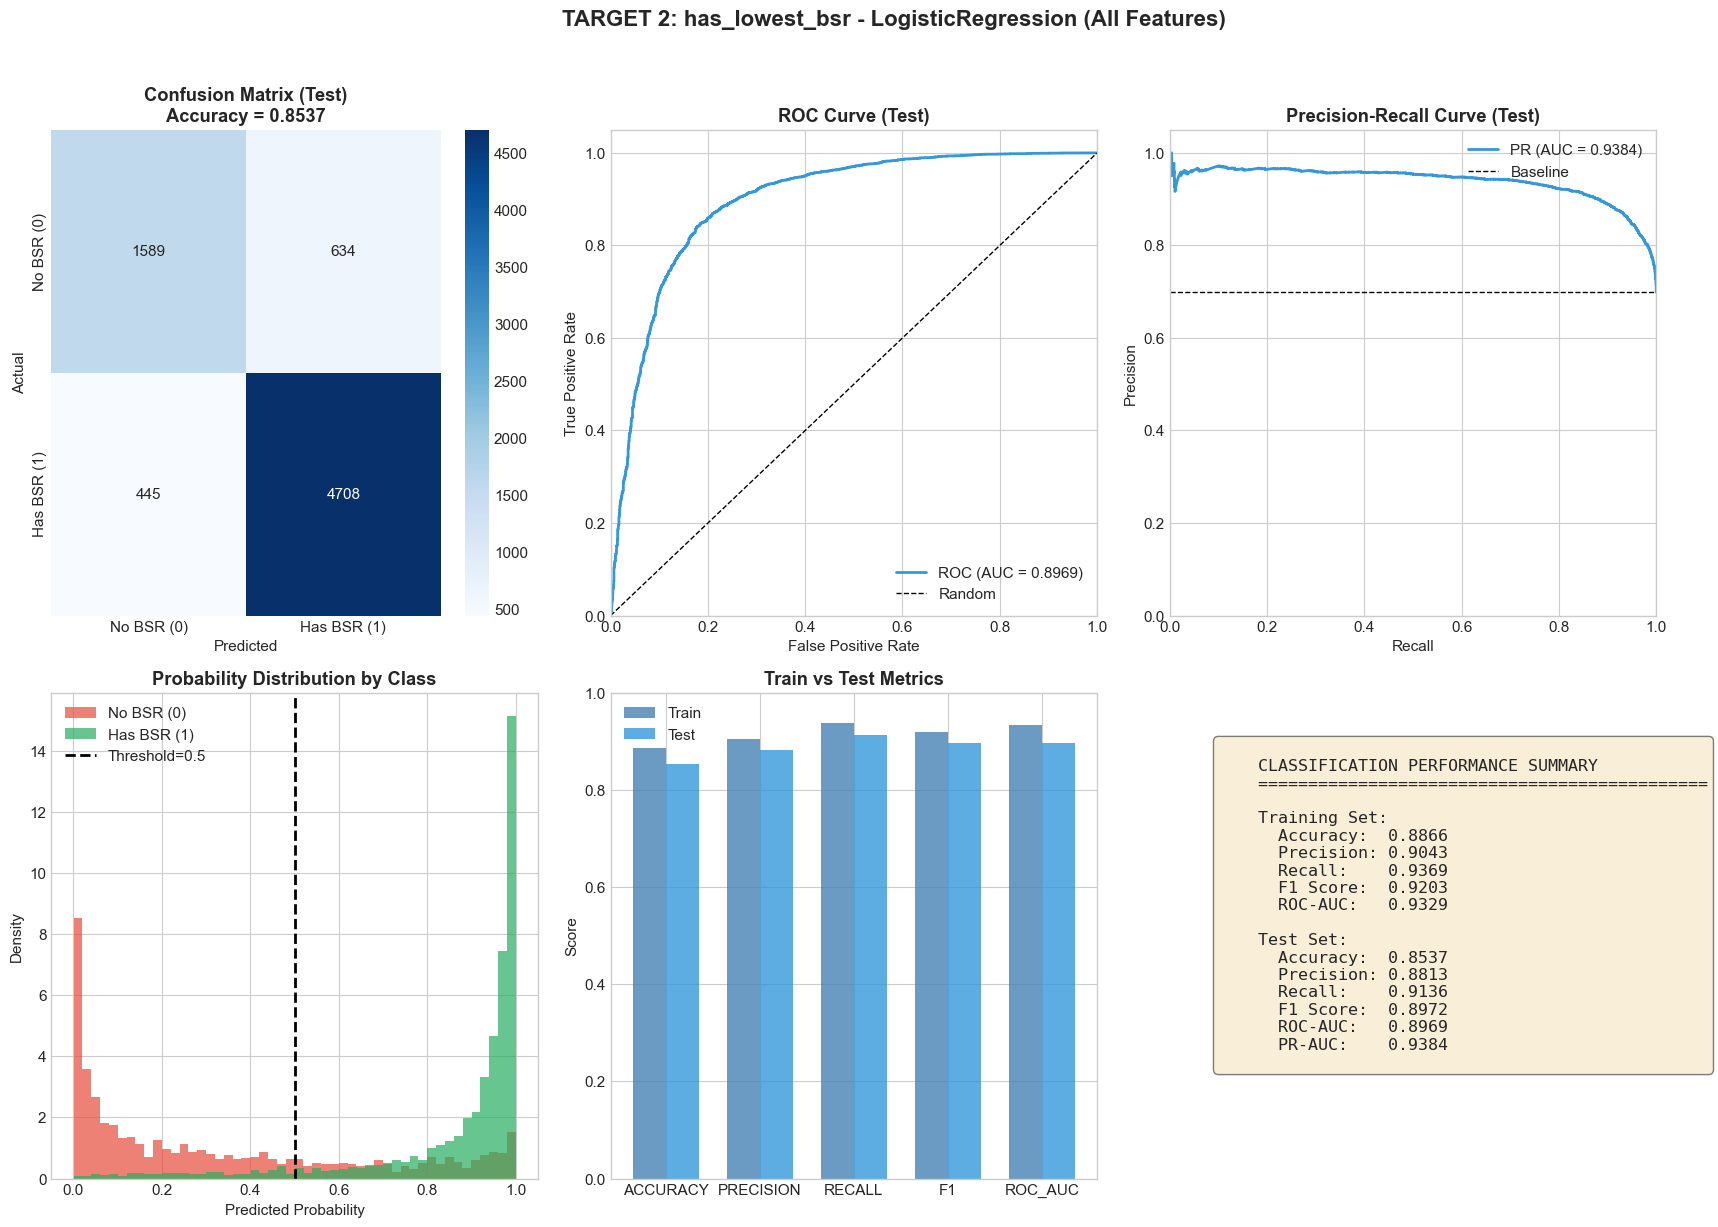

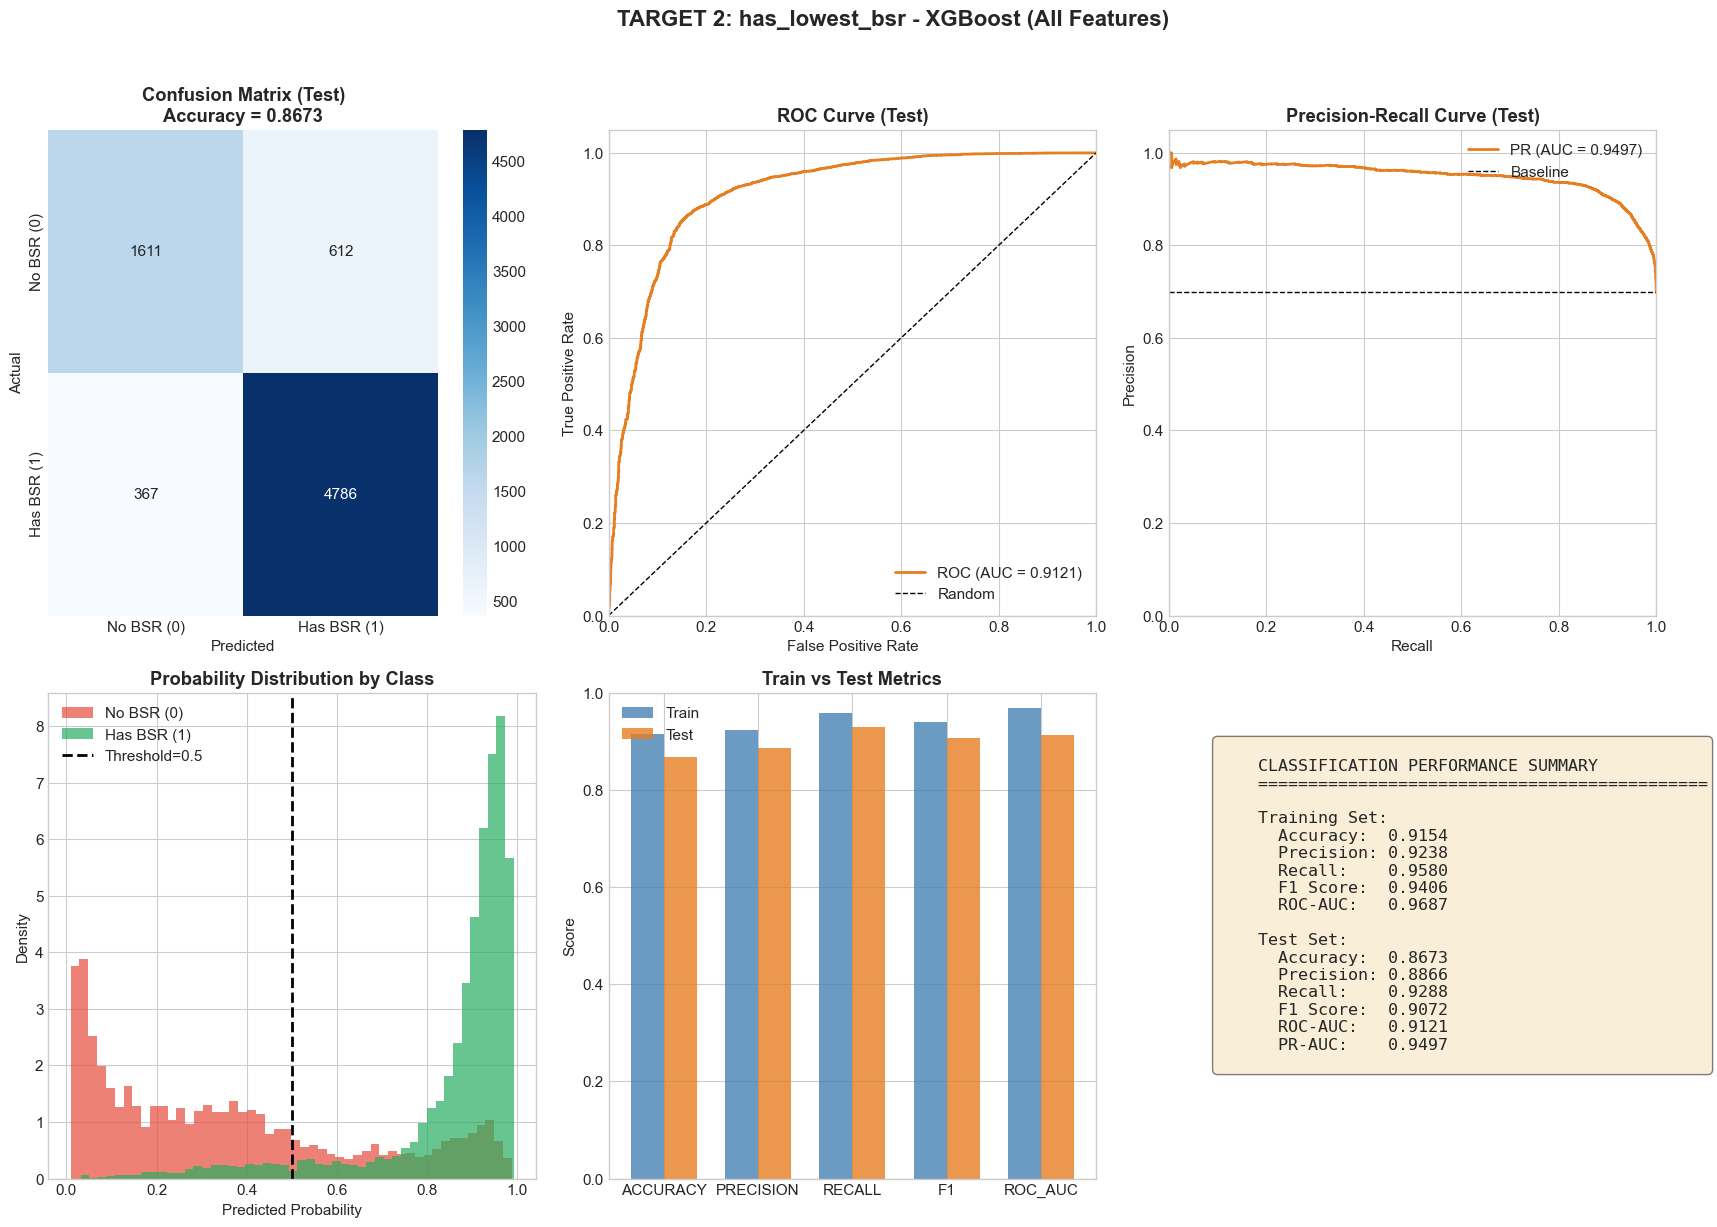

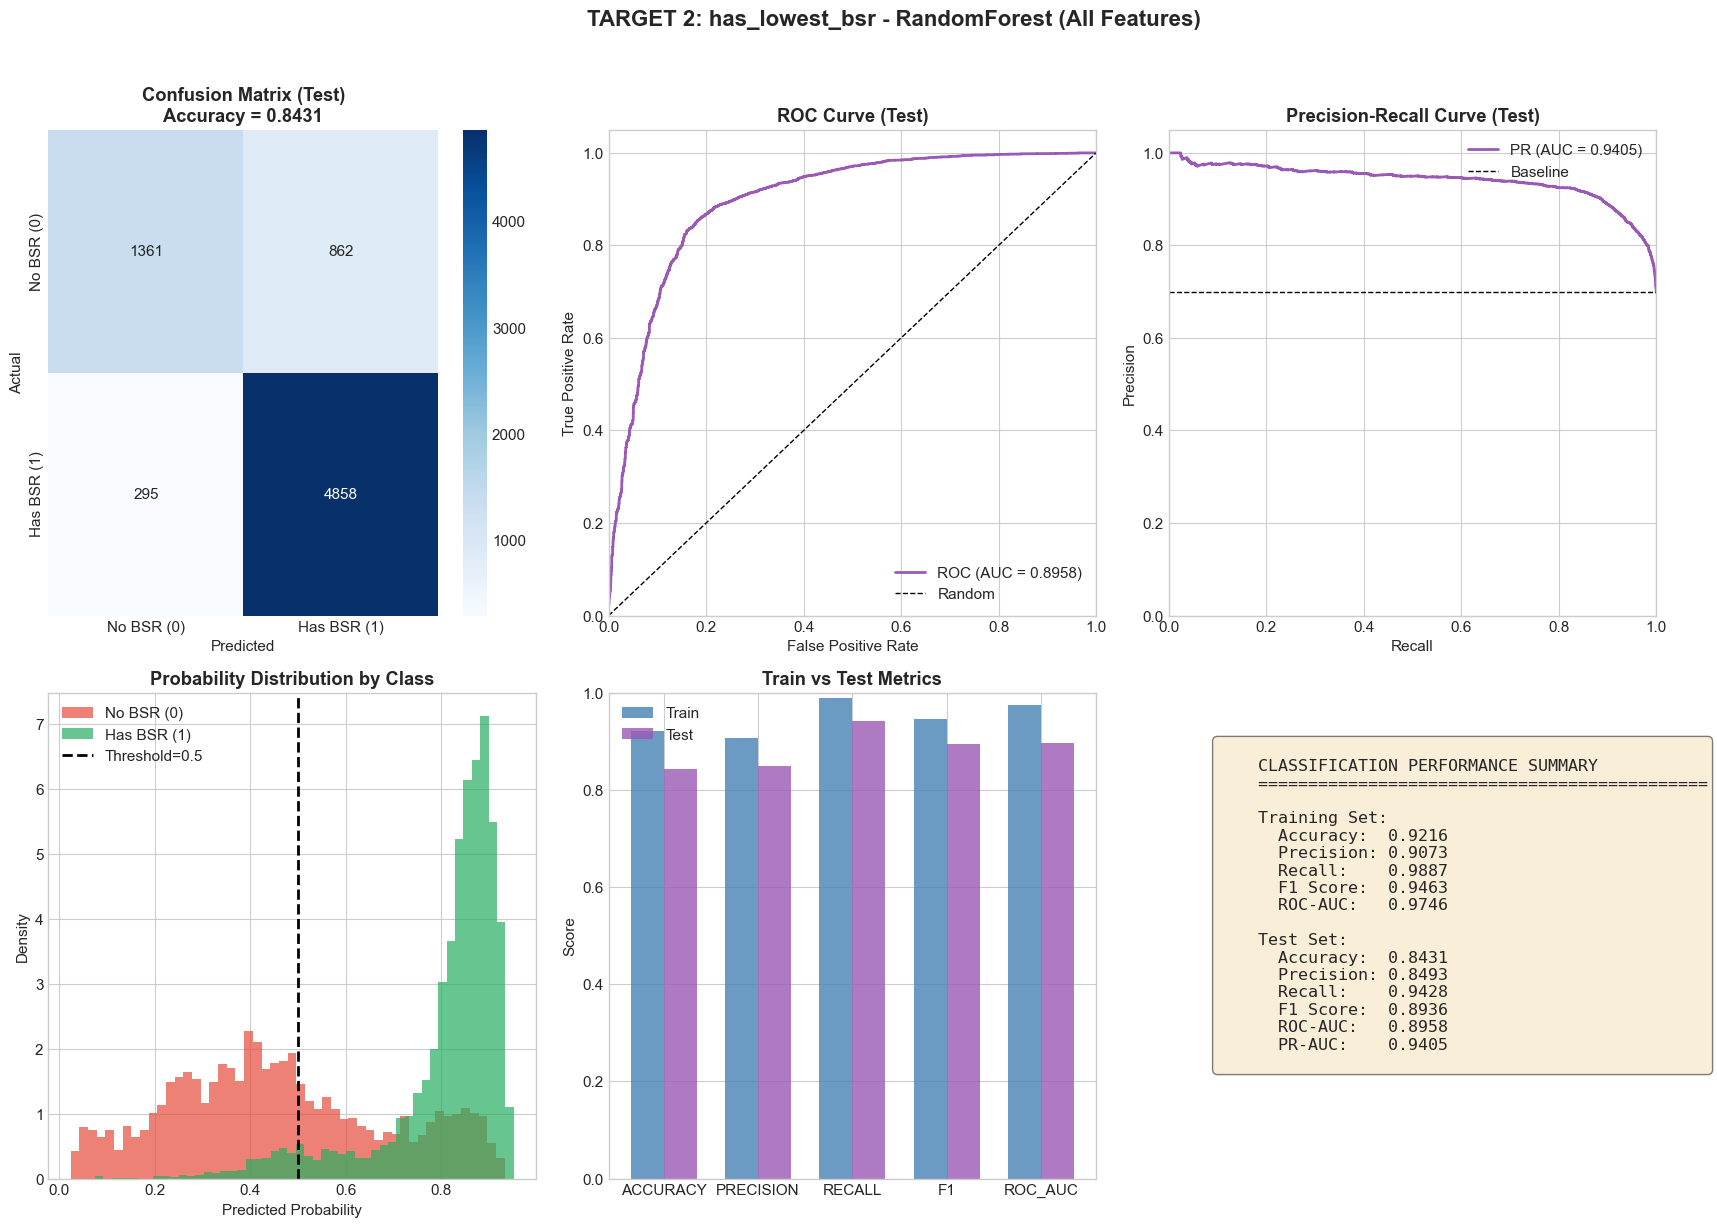

In [15]:
# Visualize results for has_lowest_bsr - All Features (All Models)
for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
    plot_classification_results(
        data_lowest_all['y_train'], data_lowest_all['y_test'],
        metrics_lowest_all[model_name],
        f'TARGET 2: has_lowest_bsr - {model_name} (All Features)',
        model_name
    )

Feature Importance - XGBoost (All Features):


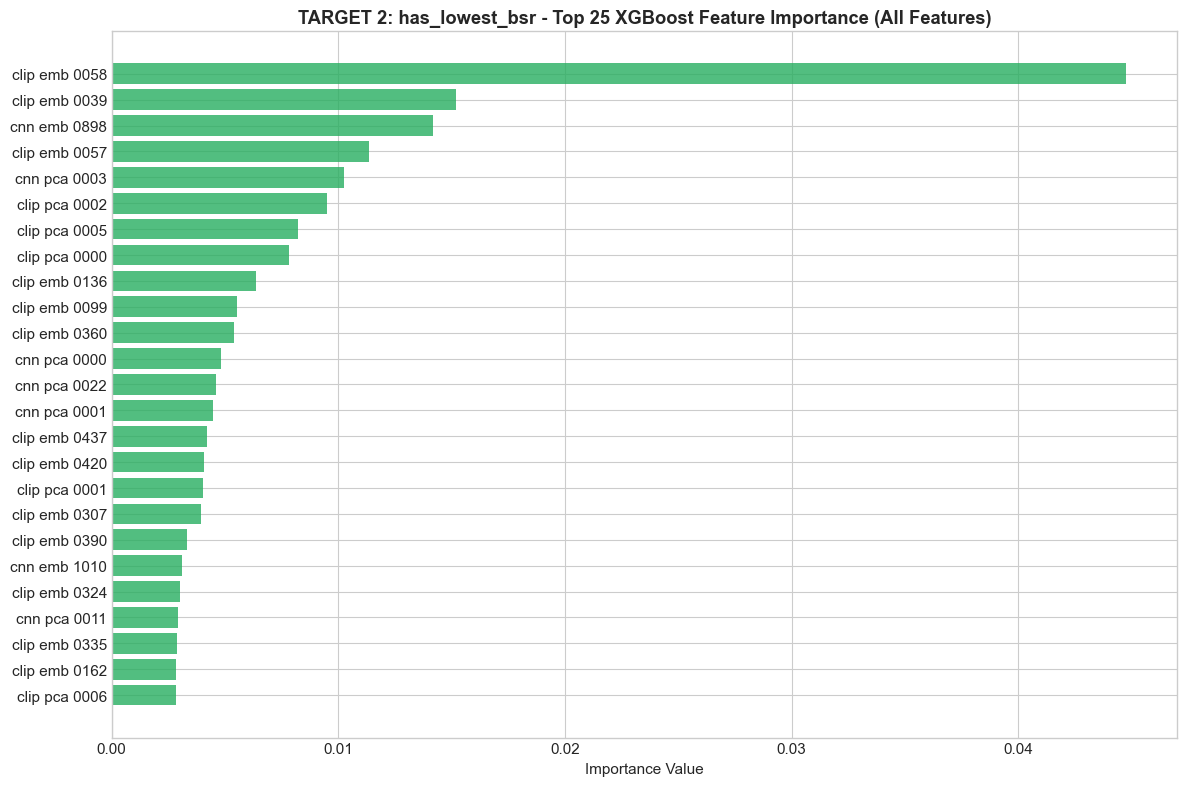

In [16]:
# Feature importance for has_lowest_bsr - All Features (top 25)
print("Feature Importance - XGBoost (All Features):")
coef_lowest_all_xgb = plot_feature_importance(
    models_lowest_all['XGBoost'], data_lowest_all['feature_names'],
    'TARGET 2: has_lowest_bsr - Top 25 XGBoost Feature Importance (All Features)',
    top_n=25
)

---
## Model Comparison Summary

In [17]:
# =============================================================================
# 9. MODEL COMPARISON SUMMARY
# =============================================================================

# Create comparison DataFrame for all models
results_list = []

# Target 1: has_main_bsr
for feature_set, data, metrics in [
    ('Top Features', data_main_top, metrics_main_top),
    ('All Features', data_main_all, metrics_main_all)
]:
    for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
        results_list.append({
            'Target': 'has_main_bsr',
            'Features': feature_set,
            'Model': model_name,
            'N_Features': len(data['feature_names']),
            'Test_Accuracy': metrics[model_name]['test_accuracy'],
            'Test_ROC_AUC': metrics[model_name]['test_roc_auc'],
            'Test_F1': metrics[model_name]['test_f1'],
            'Test_Precision': metrics[model_name]['test_precision'],
            'Test_Recall': metrics[model_name]['test_recall']
        })

# Target 2: has_lowest_bsr
for feature_set, data, metrics in [
    ('Top Features', data_lowest_top, metrics_lowest_top),
    ('All Features', data_lowest_all, metrics_lowest_all)
]:
    for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
        results_list.append({
            'Target': 'has_lowest_bsr',
            'Features': feature_set,
            'Model': model_name,
            'N_Features': len(data['feature_names']),
            'Test_Accuracy': metrics[model_name]['test_accuracy'],
            'Test_ROC_AUC': metrics[model_name]['test_roc_auc'],
            'Test_F1': metrics[model_name]['test_f1'],
            'Test_Precision': metrics[model_name]['test_precision'],
            'Test_Recall': metrics[model_name]['test_recall']
        })

comparison = pd.DataFrame(results_list)

print("="*110)
print("CLASSIFICATION MODEL COMPARISON SUMMARY")
print("="*110)
print()
print(comparison.to_string(index=False))

# Best model per target
print("\n" + "="*70)
print("BEST MODELS BY ROC-AUC")
print("="*70)
for target in ['has_main_bsr', 'has_lowest_bsr']:
    target_df = comparison[comparison['Target'] == target]
    best_idx = target_df['Test_ROC_AUC'].idxmax()
    best = target_df.loc[best_idx]
    print(f"\n{target}:")
    print(f"  Best Model: {best['Model']} ({best['Features']})")
    print(f"  ROC-AUC: {best['Test_ROC_AUC']:.4f}")
    print(f"  Accuracy: {best['Test_Accuracy']:.4f}")
    print(f"  F1: {best['Test_F1']:.4f}")

CLASSIFICATION MODEL COMPARISON SUMMARY

        Target     Features              Model  N_Features  Test_Accuracy  Test_ROC_AUC  Test_F1  Test_Precision  Test_Recall
  has_main_bsr Top Features LogisticRegression          20       0.813991      0.845751 0.871174        0.843915     0.900252
  has_main_bsr Top Features            XGBoost          20       0.843140      0.887603 0.890384        0.869863     0.911896
  has_main_bsr Top Features       RandomForest          20       0.839751      0.884114 0.888680        0.863312     0.915583
  has_main_bsr All Features LogisticRegression        7561       0.853715      0.896900 0.897189        0.881318     0.913643
  has_main_bsr All Features            XGBoost        7561       0.867272      0.912114 0.907213        0.886625     0.928779
  has_main_bsr All Features       RandomForest        7561       0.843140      0.895787 0.893590        0.849301     0.942752
has_lowest_bsr Top Features LogisticRegression          20       0.813991    

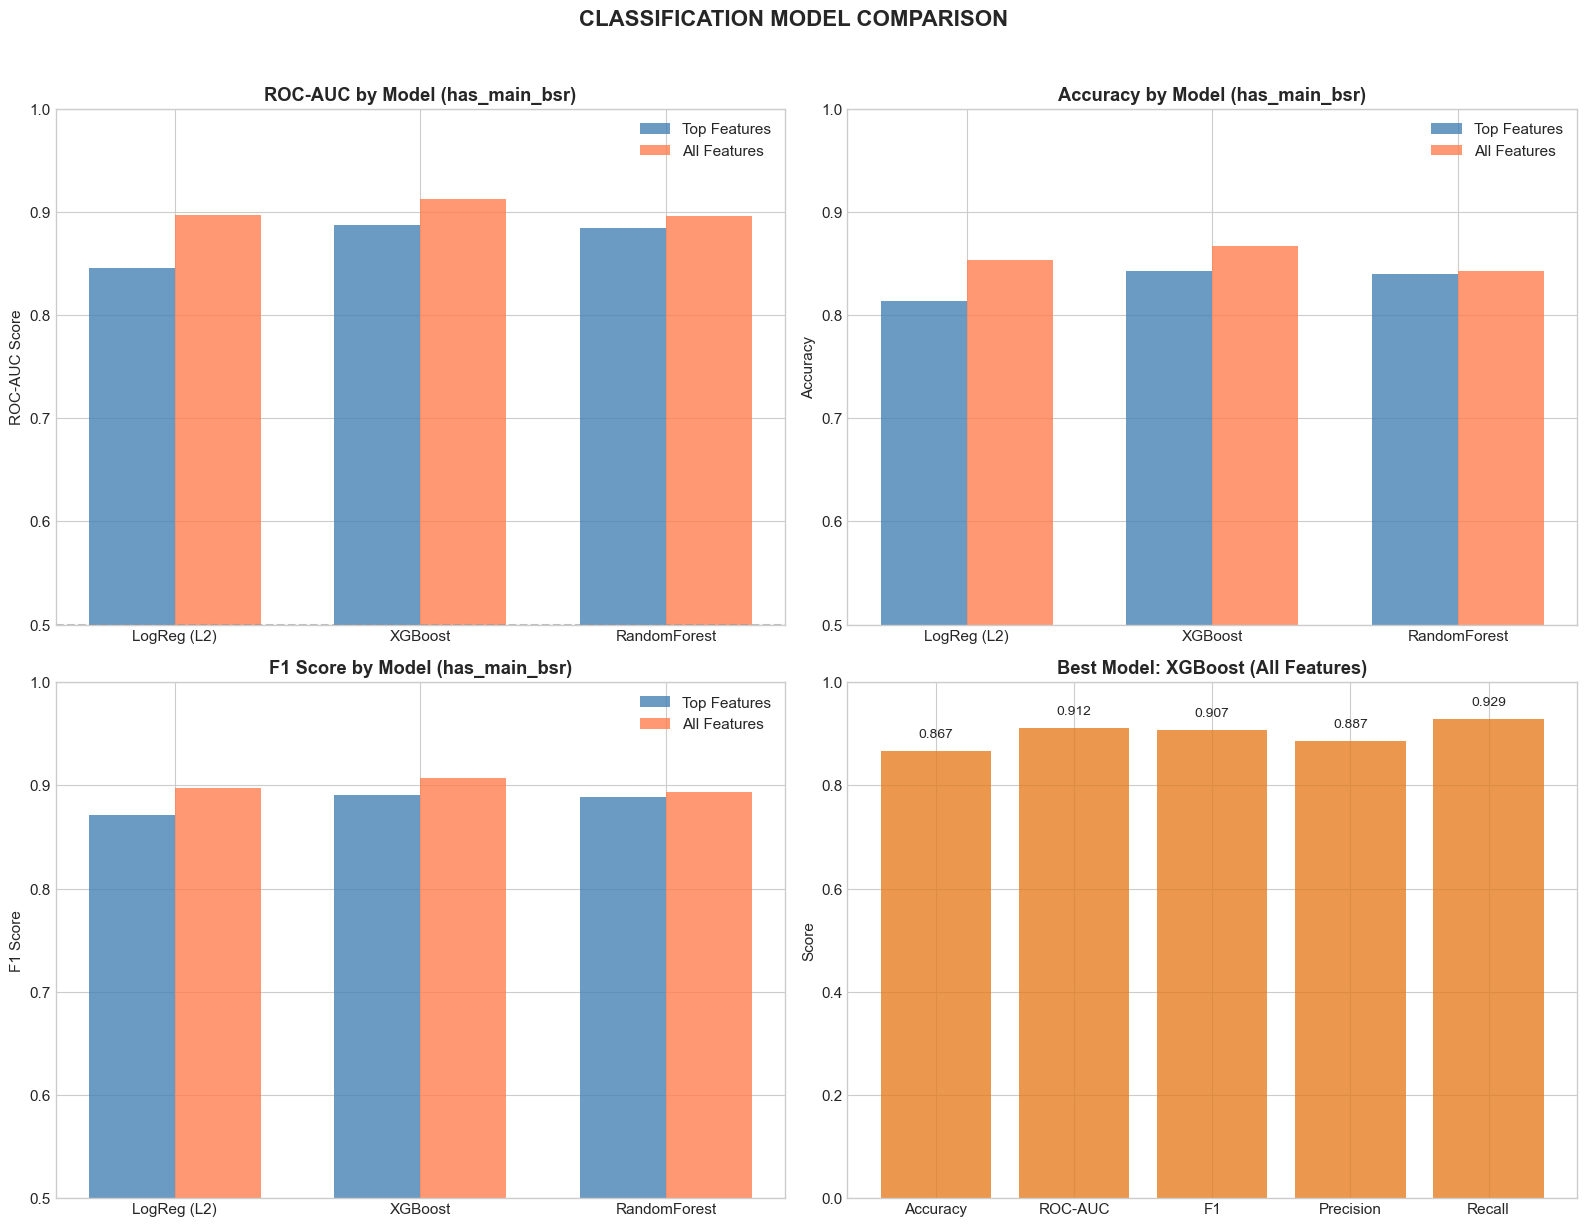

In [18]:
# Visual comparison of classification models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Filter for has_main_bsr (they're identical so we focus on one target)
main_df = comparison[comparison['Target'] == 'has_main_bsr']

# 1. ROC-AUC by Model and Feature Set
ax1 = axes[0, 0]
models = ['LogisticRegression', 'XGBoost', 'RandomForest']
x = np.arange(len(models))
width = 0.35
top_roc = main_df[main_df['Features'] == 'Top Features']['Test_ROC_AUC'].values
all_roc = main_df[main_df['Features'] == 'All Features']['Test_ROC_AUC'].values
bars1 = ax1.bar(x - width/2, top_roc, width, label='Top Features', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, all_roc, width, label='All Features', alpha=0.8, color='coral')
ax1.set_ylabel('ROC-AUC Score')
ax1.set_title('ROC-AUC by Model (has_main_bsr)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['LogReg (L2)', 'XGBoost', 'RandomForest'])
ax1.legend()
ax1.set_ylim(0.5, 1.0)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')

# 2. Accuracy by Model and Feature Set
ax2 = axes[0, 1]
top_acc = main_df[main_df['Features'] == 'Top Features']['Test_Accuracy'].values
all_acc = main_df[main_df['Features'] == 'All Features']['Test_Accuracy'].values
bars1 = ax2.bar(x - width/2, top_acc, width, label='Top Features', alpha=0.8, color='steelblue')
bars2 = ax2.bar(x + width/2, all_acc, width, label='All Features', alpha=0.8, color='coral')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy by Model (has_main_bsr)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['LogReg (L2)', 'XGBoost', 'RandomForest'])
ax2.legend()
ax2.set_ylim(0.5, 1.0)

# 3. F1 Score by Model and Feature Set
ax3 = axes[1, 0]
top_f1 = main_df[main_df['Features'] == 'Top Features']['Test_F1'].values
all_f1 = main_df[main_df['Features'] == 'All Features']['Test_F1'].values
bars1 = ax3.bar(x - width/2, top_f1, width, label='Top Features', alpha=0.8, color='steelblue')
bars2 = ax3.bar(x + width/2, all_f1, width, label='All Features', alpha=0.8, color='coral')
ax3.set_ylabel('F1 Score')
ax3.set_title('F1 Score by Model (has_main_bsr)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['LogReg (L2)', 'XGBoost', 'RandomForest'])
ax3.legend()
ax3.set_ylim(0.5, 1.0)

# 4. All Metrics for Best Model
ax4 = axes[1, 1]
best_model_idx = main_df['Test_ROC_AUC'].idxmax()
best_model_name = main_df.loc[best_model_idx, 'Model']
best_feature_set = main_df.loc[best_model_idx, 'Features']
best_row = main_df.loc[best_model_idx]

metrics_names = ['Accuracy', 'ROC-AUC', 'F1', 'Precision', 'Recall']
metrics_vals = [best_row['Test_Accuracy'], best_row['Test_ROC_AUC'], 
                best_row['Test_F1'], best_row['Test_Precision'], best_row['Test_Recall']]
colors = [MODEL_COLORS.get(best_model_name, 'steelblue')] * len(metrics_names)
bars = ax4.bar(metrics_names, metrics_vals, color=colors, alpha=0.8)
ax4.set_ylabel('Score')
ax4.set_title(f'Best Model: {best_model_name} ({best_feature_set})', fontweight='bold')
ax4.set_ylim(0, 1.0)
for bar, val in zip(bars, metrics_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('CLASSIFICATION MODEL COMPARISON', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS

Model                    Mean ROC-AUC     Std
-------------------------------------------------------
LogReg - Top             0.8504           0.0060
LogReg - All             0.8921           0.0047
XGBoost - Top            0.8873           0.0036
XGBoost - All            0.9064           0.0044
RF - Top                 0.8843           0.0032
RF - All                 0.8943           0.0044


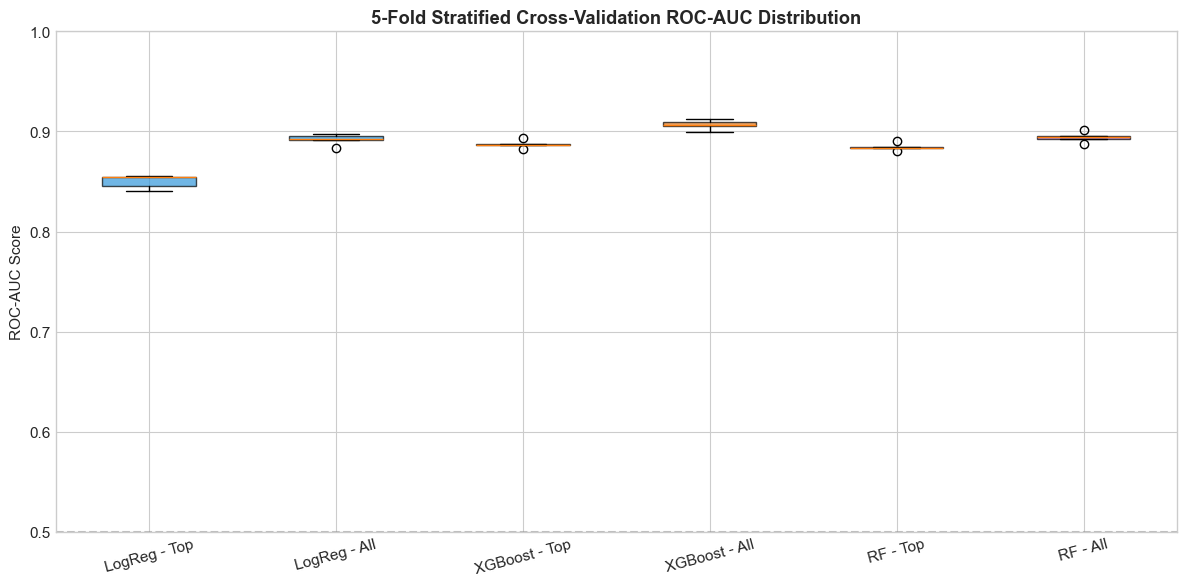

In [19]:
# =============================================================================
# 10. CROSS-VALIDATION ANALYSIS
# =============================================================================

print("="*70)
print("5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print("="*70)

# Stratified K-Fold for classification
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for each model
cv_results = {}

# Logistic Regression - Top Features
cv_lr_top = cross_val_score(
    LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42), 
    data_main_top['X_train'], 
    data_main_top['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['LogReg - Top'] = cv_lr_top

# Logistic Regression - All Features
cv_lr_all = cross_val_score(
    LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42), 
    data_main_all['X_train'], 
    data_main_all['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['LogReg - All'] = cv_lr_all

# XGBoost - Top Features
cv_xgb_top = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                  use_label_encoder=False, eval_metric='logloss', random_state=42), 
    data_main_top['X_train'], 
    data_main_top['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['XGBoost - Top'] = cv_xgb_top

# XGBoost - All Features
cv_xgb_all = cross_val_score(
    XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                  use_label_encoder=False, eval_metric='logloss', random_state=42), 
    data_main_all['X_train'], 
    data_main_all['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['XGBoost - All'] = cv_xgb_all

# Random Forest - Top Features
cv_rf_top = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), 
    data_main_top['X_train'], 
    data_main_top['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['RF - Top'] = cv_rf_top

# Random Forest - All Features
cv_rf_all = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), 
    data_main_all['X_train'], 
    data_main_all['y_train'], 
    cv=skf, scoring='roc_auc'
)
cv_results['RF - All'] = cv_rf_all

# Print results
print("\nModel                    Mean ROC-AUC     Std")
print("-" * 55)
for name, scores in cv_results.items():
    print(f"{name:24} {scores.mean():.4f}           {scores.std():.4f}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(cv_results))
colors_cv = [MODEL_COLORS['LogisticRegression'], MODEL_COLORS['LogisticRegression'],
             MODEL_COLORS['XGBoost'], MODEL_COLORS['XGBoost'],
             MODEL_COLORS['RandomForest'], MODEL_COLORS['RandomForest']]

bp = ax.boxplot([cv_results[k] for k in cv_results.keys()], 
                positions=positions, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(list(cv_results.keys()), rotation=15)
ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold Stratified Cross-Validation ROC-AUC Distribution', fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

---
## Final Summary and Conclusions

Summary of classification models trained for predicting BSR presence.

In [20]:
# =============================================================================
# 11. FINAL SUMMARY - CLASSIFICATION MODELS
# =============================================================================

print("="*90)
print("CLASSIFICATION BASELINE MODELING SUMMARY")
print("="*90)

print("""
TASK: Binary Classification - Predicting whether a product has a BSR rank

TARGETS:
  - has_main_bsr: Whether product has a main BSR rank (0=No, 1=Yes)
  - has_lowest_bsr: Whether product has any BSR rank (0=No, 1=Yes)

MODELS TRAINED:
  1. Logistic Regression (L2 Regularized) - Linear classifier, interpretable coefficients
  2. XGBoost Classifier - Gradient boosting, handles non-linear patterns
  3. Random Forest Classifier - Ensemble of decision trees

FEATURE SETS:
  - Top Features: Top 20 features from EDA (based on Point-Biserial correlation, 
    Cohen's d effect size, and Mutual Information)
  - All Features: All available image features (~7000+)

KEY METRICS:
  - ROC-AUC: Area under ROC curve (primary metric for imbalanced classification)
  - Accuracy: Overall classification accuracy
  - F1 Score: Harmonic mean of precision and recall
  - Precision/Recall: Trade-off between false positives and false negatives
""")

# Print best results
print("\n" + "="*70)
print("BEST MODEL PERFORMANCE (has_main_bsr)")
print("="*70)

# Find best overall model
best_roc = 0
best_info = {}
for feature_set, metrics in [('Top Features', metrics_main_top), ('All Features', metrics_main_all)]:
    for model_name in ['LogisticRegression', 'XGBoost', 'RandomForest']:
        roc = metrics[model_name]['test_roc_auc']
        if roc > best_roc:
            best_roc = roc
            best_info = {
                'model': model_name,
                'features': feature_set,
                'roc_auc': roc,
                'accuracy': metrics[model_name]['test_accuracy'],
                'f1': metrics[model_name]['test_f1'],
                'precision': metrics[model_name]['test_precision'],
                'recall': metrics[model_name]['test_recall']
            }

print(f"\nBest Model: {best_info['model']} ({best_info['features']})")
print(f"  ROC-AUC:   {best_info['roc_auc']:.4f}")
print(f"  Accuracy:  {best_info['accuracy']:.4f}")
print(f"  F1 Score:  {best_info['f1']:.4f}")
print(f"  Precision: {best_info['precision']:.4f}")
print(f"  Recall:    {best_info['recall']:.4f}")

CLASSIFICATION BASELINE MODELING SUMMARY

TASK: Binary Classification - Predicting whether a product has a BSR rank

TARGETS:
  - has_main_bsr: Whether product has a main BSR rank (0=No, 1=Yes)
  - has_lowest_bsr: Whether product has any BSR rank (0=No, 1=Yes)

MODELS TRAINED:
  1. Logistic Regression (L2 Regularized) - Linear classifier, interpretable coefficients
  2. XGBoost Classifier - Gradient boosting, handles non-linear patterns
  3. Random Forest Classifier - Ensemble of decision trees

FEATURE SETS:
  - Top Features: Top 20 features from EDA (based on Point-Biserial correlation, 
    Cohen's d effect size, and Mutual Information)
  - All Features: All available image features (~7000+)

KEY METRICS:
  - ROC-AUC: Area under ROC curve (primary metric for imbalanced classification)
  - Accuracy: Overall classification accuracy
  - F1 Score: Harmonic mean of precision and recall
  - Precision/Recall: Trade-off between false positives and false negatives


BEST MODEL PERFORMANCE (h